# Transfer Learning and Representation Comparison

This notebook is organized to compare:

## 1. Supervised baselines
- ResNet18 with FC-only training (all layers forzen)
- ResNet18 with layer4 unfrozen

## 2. Representation evaluation
- Linear probe
- kNN
- Prototype classifier

## 3. Supervised contrastive learning (SupCon)
- Backbone feature `h` (raw feature extracted from ResNet18)
- Projection feature `z` (feature after projection)

structure:

x --> ResNet Encoder --> h --> Projection Head --> z

## 4. Rejection / unknown thresholding
- Prototype distance + threshold

---

## Dataset structure
data: https://www.kaggle.com/datasets/benpepperpots/rust-iron-dataset?select=train


rust_dataset/

    train/

        class_0/
        class_1/
    val/

        class_0/
        class_1/

# Imports, Config, device setup

In [1]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score

In [2]:
# Global config

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0   
DATA_ROOT = Path("rust_dataset") 

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "test"

In [3]:
# Device setup

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # for mac
    print("Using Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print("Device:", DEVICE)

Using Apple MPS
Device: mps


In [4]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Seed set.")

Seed set.


In [5]:
# Supervised train and val transform --> for resNet

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# SupCon transform

class TwoCropTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return [self.transform(x), self.transform(x)]


supcon_base_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

supcon_tf = TwoCropTransform(supcon_base_tf)
print("SupCon transform ready.")

SupCon transform ready.


# Dataset and Dataloader setup

In [7]:
# Datasets

# Supervised training dataset
train_ds_sup = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)

# Evaluation datasets
train_ds_eval = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
val_ds_eval   = datasets.ImageFolder(VAL_DIR, transform=eval_tf)

# SupCon dataset
train_ds_supcon = datasets.ImageFolder(TRAIN_DIR, transform=supcon_tf)

CLASS_NAMES = train_ds_sup.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
print("Train samples:", len(train_ds_sup))
print("Validation samples:", len(val_ds_eval))

Classes: ['CORROSION', 'NOCORROSION']
Number of classes: 2
Train samples: 1273
Validation samples: 182


In [8]:
# DataLoaders

train_dl_sup = DataLoader(
    train_ds_sup,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

train_dl_eval = DataLoader(
    train_ds_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

val_dl_eval = DataLoader(
    val_ds_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

train_dl_supcon = DataLoader(
    train_ds_supcon,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

print("Dataloaders ready.")

Dataloaders ready.


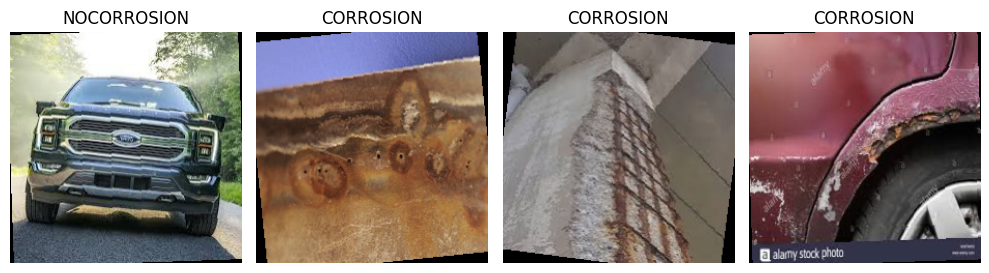

In [9]:
# Visual check

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)

images, labels = next(iter(train_dl_sup))

plt.figure(figsize=(10, 4))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Section 1 — Supervised Baselines

code adapted from: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

Train and save:

1. ResNet18 FC-only
2. ResNet18 with layer4 unfrozen

Checkpoints will be used later for:
- direct classifier comparison
- feature extraction
- linear probe
- kNN
- prototype classification

In [10]:
def make_resnet18_fc_only(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # Train classifier only
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [11]:
def make_resnet18_layer4(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # Train classifier
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [12]:
# fucntion to check param
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [13]:
resnet_fc_model = make_resnet18_fc_only(NUM_CLASSES).to(DEVICE)
resnet_l4_model = make_resnet18_layer4(NUM_CLASSES).to(DEVICE)

print("FC-only trainable params:", count_trainable_params(resnet_fc_model))
print("Layer4 unfrozen trainable params:", count_trainable_params(resnet_l4_model))

FC-only trainable params: 1026
Layer4 unfrozen trainable params: 8394754


## Section 1B — Training Utilities

define functions for reuse:
- training for one epoch
- validation for one epoch
- full training loop with checkpoint saving

In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [15]:
# full training loop function -- 10 epochs

def fit_supervised_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    checkpoint_path=None
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = eval_one_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)

    # restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc

In [16]:
def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

## Section 1C — Train FC ResNet18 and Unfreeze layer 4 of ResNet18

Epoch 01/10 | train_loss=0.5483 | train_acc=0.7133 | val_loss=0.3457 | val_acc=0.8736
Epoch 02/10 | train_loss=0.3401 | train_acc=0.8712 | val_loss=0.2599 | val_acc=0.9231
Epoch 03/10 | train_loss=0.2950 | train_acc=0.8743 | val_loss=0.2204 | val_acc=0.9396
Epoch 04/10 | train_loss=0.2531 | train_acc=0.9104 | val_loss=0.2616 | val_acc=0.8901
Epoch 05/10 | train_loss=0.2745 | train_acc=0.8806 | val_loss=0.2572 | val_acc=0.8846
Epoch 06/10 | train_loss=0.2286 | train_acc=0.9049 | val_loss=0.2113 | val_acc=0.9176
Epoch 07/10 | train_loss=0.1978 | train_acc=0.9262 | val_loss=0.1982 | val_acc=0.9121
Epoch 08/10 | train_loss=0.2150 | train_acc=0.9167 | val_loss=0.2522 | val_acc=0.8956
Epoch 09/10 | train_loss=0.2095 | train_acc=0.9199 | val_loss=0.2257 | val_acc=0.9176
Epoch 10/10 | train_loss=0.2194 | train_acc=0.9191 | val_loss=0.1862 | val_acc=0.9341
Best FC-only val acc: 0.9395604395604396


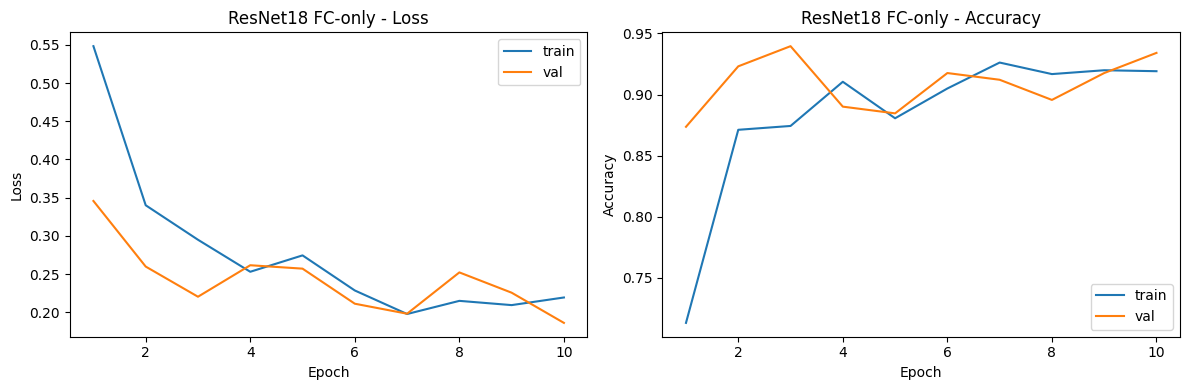

Epoch 01/10 | train_loss=0.2539 | train_acc=0.8892 | val_loss=0.1361 | val_acc=0.9451
Epoch 02/10 | train_loss=0.0816 | train_acc=0.9764 | val_loss=0.0928 | val_acc=0.9670
Epoch 03/10 | train_loss=0.0383 | train_acc=0.9882 | val_loss=0.1023 | val_acc=0.9505
Epoch 04/10 | train_loss=0.0286 | train_acc=0.9929 | val_loss=0.1133 | val_acc=0.9560
Epoch 05/10 | train_loss=0.0208 | train_acc=0.9937 | val_loss=0.1178 | val_acc=0.9505
Epoch 06/10 | train_loss=0.0185 | train_acc=0.9898 | val_loss=0.1772 | val_acc=0.9451
Epoch 07/10 | train_loss=0.0099 | train_acc=0.9984 | val_loss=0.1563 | val_acc=0.9451
Epoch 08/10 | train_loss=0.0085 | train_acc=0.9976 | val_loss=0.1436 | val_acc=0.9560
Epoch 09/10 | train_loss=0.0142 | train_acc=0.9953 | val_loss=0.1483 | val_acc=0.9505
Epoch 10/10 | train_loss=0.0196 | train_acc=0.9937 | val_loss=0.2308 | val_acc=0.9396
Best layer4 val acc: 0.967032967032967


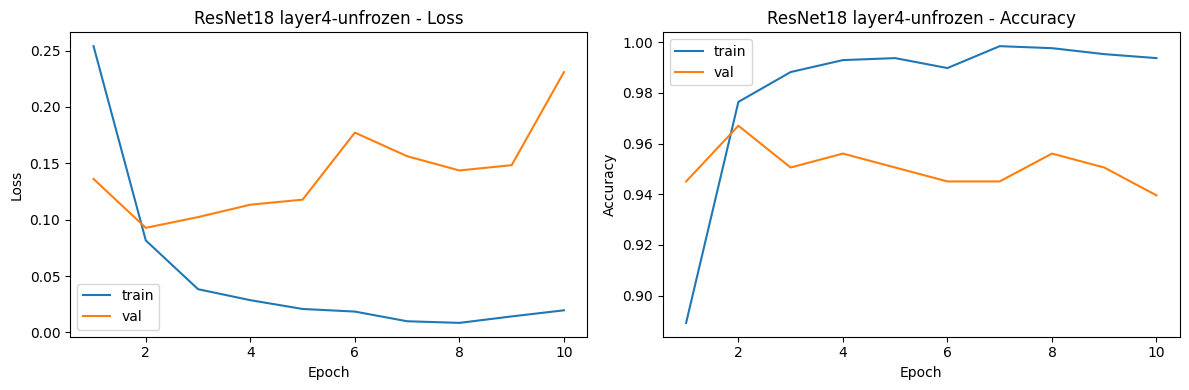

In [17]:
# setup and train fc only
EPOCHS_FC = 10
LR_FC = 1e-3

resnet_fc_model = make_resnet18_fc_only(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_fc = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_fc_model.parameters()),
    lr=LR_FC
)

resnet_fc_model, history_fc, best_val_acc_fc = fit_supervised_model(
    model=resnet_fc_model,
    train_loader=train_dl_sup,
    val_loader=val_dl_eval,
    criterion=criterion,
    optimizer=optimizer_fc,
    device=DEVICE,
    epochs=EPOCHS_FC,
    checkpoint_path="resnet18_fc_only_best.pth"
)

print("Best FC-only val acc:", best_val_acc_fc)
plot_history(history_fc, title="ResNet18 FC-only")


# setup and train layer 4 of resnet18
EPOCHS_L4 = 10
LR_L4 = 1e-4

resnet_l4_model = make_resnet18_layer4(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_l4 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_l4_model.parameters()),
    lr=LR_L4
)

resnet_l4_model, history_l4, best_val_acc_l4 = fit_supervised_model(
    model=resnet_l4_model,
    train_loader=train_dl_sup,
    val_loader=val_dl_eval,
    criterion=criterion,
    optimizer=optimizer_l4,
    device=DEVICE,
    epochs=EPOCHS_L4,
    checkpoint_path="resnet18_layer4_best.pth"
)

print("Best layer4 val acc:", best_val_acc_l4)
plot_history(history_l4, title="ResNet18 layer4-unfrozen")

In [18]:
# compare two model
print(f"FC only best val accuracy:   {best_val_acc_fc:.4f}")
print(f"Layer4 best val accuracy:    {best_val_acc_l4:.4f}")

FC only best val accuracy:   0.9396
Layer4 best val accuracy:    0.9670


### Note
the model with more trainable parameter reaches a higher result

## Section 2 — Feature Extraction

After training the models, start feature extraction:

1. load the best supervised model
2. extract from `avgpool` features
3. compare:
   - linear probe
   - kNN
   - prototype classifier

In [19]:
from torchvision.models.feature_extraction import create_feature_extractor

In [20]:
# Use the better supervised model as the feature source

if best_val_acc_l4 >= best_val_acc_fc:
    best_supervised_model = resnet_l4_model
    best_supervised_name = "resnet18_layer4"
else:
    best_supervised_model = resnet_fc_model
    best_supervised_name = "resnet18_fc_only"

print("Using feature source:", best_supervised_name)

Using feature source: resnet18_layer4


In [21]:
# Extract features from the avgpool node
# avgpool output shape: [B, 512, 1, 1]
# set the model into a feature extraction mode
resnet_feat_extractor = create_feature_extractor(
    best_supervised_model,
    return_nodes={"avgpool": "emb"}
).to(DEVICE)

resnet_feat_extractor.eval()
print("Feature extractor ready.")

Feature extractor ready.


In [22]:
# convert feature to emdedding
def extract_embeddings(feature_extractor, dataloader, device):
    feature_extractor.eval()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = feature_extractor(images)
            emb = outputs["emb"]                  # [B, 512, 1, 1]
            emb = torch.flatten(emb, start_dim=1)  # [B, 512]

            all_embeddings.append(emb.cpu())
            all_labels.append(labels.cpu())

    Z = torch.cat(all_embeddings, dim=0)
    y = torch.cat(all_labels, dim=0)

    return Z, y

In [23]:
# extract emdedding from train
Z_resnet_train, y_train = extract_embeddings(
    resnet_feat_extractor,
    train_dl_eval,
    DEVICE
)

print("Z_resnet_train shape:", Z_resnet_train.shape) # number of of image and the dimension
print("y_train shape:", y_train.shape) # label of image

Z_resnet_train shape: torch.Size([1273, 512])
y_train shape: torch.Size([1273])


In [24]:
# extract emdedding from val
Z_resnet_val, y_val = extract_embeddings(
    resnet_feat_extractor,
    val_dl_eval,
    DEVICE
)

print("Z_resnet_val shape:", Z_resnet_val.shape)
print("y_val shape:", y_val.shape)

Z_resnet_val shape: torch.Size([182, 512])
y_val shape: torch.Size([182])


In [25]:
print("Train embedding dim:", Z_resnet_train.shape[1])
print("Validation embedding dim:", Z_resnet_val.shape[1])

print("Unique train labels:", torch.unique(y_train))
print("Unique val labels:", torch.unique(y_val))

Train embedding dim: 512
Validation embedding dim: 512
Unique train labels: tensor([0, 1])
Unique val labels: tensor([0, 1])


In [26]:
# normalize the veector
def l2_normalize_torch(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)

In [27]:
Z_resnet_train_l2 = l2_normalize_torch(Z_resnet_train)
Z_resnet_val_l2   = l2_normalize_torch(Z_resnet_val)

print("Normalized train shape:", Z_resnet_train_l2.shape)
print("Normalized val shape:", Z_resnet_val_l2.shape)

Normalized train shape: torch.Size([1273, 512])
Normalized val shape: torch.Size([182, 512])


now both versions of the ResNet embeddings are set:

- `Z_resnet_train`, `Z_resnet_val`
  - raw extracted features

- `Z_resnet_train_l2`, `Z_resnet_val_l2`
  - L2-normalized features

In [28]:
for class_idx, class_name in enumerate(CLASS_NAMES):
    n_train = int((y_train == class_idx).sum())
    n_val = int((y_val == class_idx).sum())
    print(f"{class_name}: train={n_train}, val={n_val}")

CORROSION: train=693, val=99
NOCORROSION: train=580, val=83


In [29]:
torch.save(
    {
        "Z_resnet_train": Z_resnet_train,
        "Z_resnet_val": Z_resnet_val,
        "Z_resnet_train_l2": Z_resnet_train_l2,
        "Z_resnet_val_l2": Z_resnet_val_l2,
        "y_train": y_train,
        "y_val": y_val,
        "class_names": CLASS_NAMES,
        "feature_source": best_supervised_name,
    },
    "resnet_features.pt"
)

print("Saved features to resnet_features.pt")

Saved features to resnet_features.pt


## Section 3 — Linear Probe on ResNet Features

Use linear probe to test whether the extracted features are linearly separable.

Steps:
- freeze backbone
- use extracted embeddings as input
- train on a linear classifier

test on:
1. raw ResNet features
2. L2-normalized ResNet features

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
X_train_raw = Z_resnet_train.numpy()
X_val_raw   = Z_resnet_val.numpy()

X_train_l2 = Z_resnet_train_l2.numpy()
X_val_l2   = Z_resnet_val_l2.numpy()

y_train_np = y_train.numpy()
y_val_np   = y_val.numpy()

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("y_train:", y_train_np.shape)
print("y_val:", y_val_np.shape)

X_train_raw: (1273, 512)
X_val_raw: (182, 512)
y_train: (1273,)
y_val: (182,)


In [32]:
def run_linear_probe(X_train, y_train, X_val, y_val, max_iter=2000, C=1.0):
    clf = LogisticRegression(
        max_iter=max_iter,
        C=C,
        solver="lbfgs"
    )

    clf.fit(X_train, y_train)

    train_preds = clf.predict(X_train)
    val_preds = clf.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    return clf, train_preds, val_preds, train_acc, val_acc

In [33]:
lp_raw_clf, lp_raw_train_preds, lp_raw_val_preds, lp_raw_train_acc, lp_raw_val_acc = run_linear_probe(
    X_train_raw,
    y_train_np,
    X_val_raw,
    y_val_np
)

print(f"Linear probe (raw features) train accuracy: {lp_raw_train_acc:.4f}")
print(f"Linear probe (raw features) val accuracy:   {lp_raw_val_acc:.4f}")

Linear probe (raw features) train accuracy: 1.0000
Linear probe (raw features) val accuracy:   0.9505


In [34]:
lp_l2_clf, lp_l2_train_preds, lp_l2_val_preds, lp_l2_train_acc, lp_l2_val_acc = run_linear_probe(
    X_train_l2,
    y_train_np,
    X_val_l2,
    y_val_np
)

print(f"Linear probe (L2 features) train accuracy: {lp_l2_train_acc:.4f}")
print(f"Linear probe (L2 features) val accuracy:   {lp_l2_val_acc:.4f}")

Linear probe (L2 features) train accuracy: 0.9953
Linear probe (L2 features) val accuracy:   0.9560


In [35]:
print("Linear Probe Comparison")
print(f"Raw features val accuracy: {lp_raw_val_acc:.4f}")
print(f"L2  features val accuracy: {lp_l2_val_acc:.4f}")

Linear Probe Comparison
Raw features val accuracy: 0.9505
L2  features val accuracy: 0.9560


In [36]:
if lp_l2_val_acc >= lp_raw_val_acc:
    lp_best_name = "resnet_linear_probe_l2"
    lp_best_clf = lp_l2_clf
    lp_best_val_preds = lp_l2_val_preds
    lp_best_val_acc = lp_l2_val_acc
else:
    lp_best_name = "resnet_linear_probe_raw"
    lp_best_clf = lp_raw_clf
    lp_best_val_preds = lp_raw_val_preds
    lp_best_val_acc = lp_raw_val_acc

print("Best linear probe performance:", lp_best_name)
print("Best linear probe val accuracy:", lp_best_val_acc)

Best linear probe performance: resnet_linear_probe_l2
Best linear probe val accuracy: 0.9560439560439561


In [37]:
# print the results using the better feature
print(classification_report(
    y_val_np,
    lp_best_val_preds,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   CORROSION       0.97      0.95      0.96        99
 NOCORROSION       0.94      0.96      0.95        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



In [38]:
cm_lp = confusion_matrix(y_val_np, lp_best_val_preds)
print(cm_lp)

[[94  5]
 [ 3 80]]


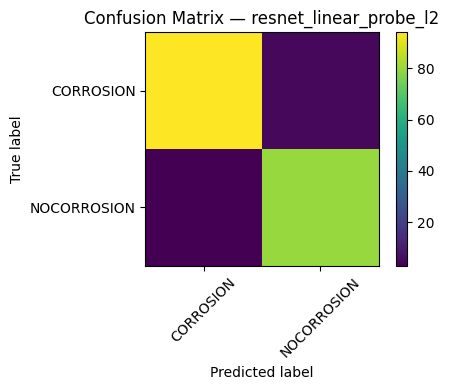

In [39]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_lp, interpolation="nearest")
plt.title(f"Confusion Matrix — {lp_best_name}")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [40]:
linear_probe_results = {
    "raw_val_acc": lp_raw_val_acc,
    "l2_val_acc": lp_l2_val_acc,
    "best_name": lp_best_name,
    "best_val_acc": lp_best_val_acc
}

torch.save(linear_probe_results, "linear_probe_results.pt")
print("Saved linear probe results.")

Saved linear probe results.


### short conclusion

Linear probe indicates whether the feature space is already well separated using a linear method.

Result:
The accuracy of the l2 regularized feature rreaches around 0.956 on val

meaning:
- the backbone features are strong

next step we would compare:
- kNN on the same features
- prototype classifier on the same features

## Section 4 — kNN on ResNet Features

evaluate the same ResNet embeddings using k-nearest neighbors.

compare:
1. raw ResNet features
2. L2 normalized ResNet features

swap using multiple values of `k`.

In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
def run_knn(X_train, y_train, X_val, y_val, k=5, metric="euclidean"):
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric=metric
    )

    knn.fit(X_train, y_train)

    train_preds = knn.predict(X_train)
    val_preds = knn.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    return knn, train_preds, val_preds, train_acc, val_acc

In [43]:
k_values = [1, 3, 5, 7, 9, 11]
print("k values:", k_values)

k values: [1, 3, 5, 7, 9, 11]


In [44]:
knn_raw_results = []

for k in k_values:
    _, train_preds, val_preds, train_acc, val_acc = run_knn(
        X_train_raw,
        y_train_np,
        X_val_raw,
        y_val_np,
        k=k,
        metric="euclidean"
    )

    knn_raw_results.append({
        "k": k,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_preds": val_preds
    })

    print(f"[RAW] k={k:2d} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

[RAW] k= 1 | train_acc=1.0000 | val_acc=0.9725
[RAW] k= 3 | train_acc=0.9976 | val_acc=0.9615
[RAW] k= 5 | train_acc=0.9976 | val_acc=0.9725
[RAW] k= 7 | train_acc=0.9953 | val_acc=0.9615
[RAW] k= 9 | train_acc=0.9937 | val_acc=0.9560
[RAW] k=11 | train_acc=0.9945 | val_acc=0.9560


In [45]:
knn_l2_results = []

for k in k_values:
    _, train_preds, val_preds, train_acc, val_acc = run_knn(
        X_train_l2,
        y_train_np,
        X_val_l2,
        y_val_np,
        k=k,
        metric="euclidean"
    )

    knn_l2_results.append({
        "k": k,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_preds": val_preds
    })

    print(f"[L2 ] k={k:2d} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

[L2 ] k= 1 | train_acc=1.0000 | val_acc=0.9615
[L2 ] k= 3 | train_acc=0.9976 | val_acc=0.9560
[L2 ] k= 5 | train_acc=0.9969 | val_acc=0.9560
[L2 ] k= 7 | train_acc=0.9976 | val_acc=0.9560
[L2 ] k= 9 | train_acc=0.9976 | val_acc=0.9560
[L2 ] k=11 | train_acc=0.9953 | val_acc=0.9615


In [46]:
best_knn_raw = max(knn_raw_results, key=lambda x: x["val_acc"])

print("Best RAW kNN result")
print("k:", best_knn_raw["k"])
print("train acc:", best_knn_raw["train_acc"])
print("val acc:", best_knn_raw["val_acc"])

best_knn_l2 = max(knn_l2_results, key=lambda x: x["val_acc"])

print("Best L2 kNN result")
print("k:", best_knn_l2["k"])
print("train acc:", best_knn_l2["train_acc"])
print("val acc:", best_knn_l2["val_acc"])

Best RAW kNN result
k: 1
train acc: 1.0
val acc: 0.9725274725274725
Best L2 kNN result
k: 1
train acc: 1.0
val acc: 0.9615384615384616


In [47]:
if best_knn_l2["val_acc"] >= best_knn_raw["val_acc"]:
    knn_best_name = "resnet_knn_l2"
    knn_best_result = best_knn_l2
    knn_best_features = "L2"
else:
    knn_best_name = "resnet_knn_raw"
    knn_best_result = best_knn_raw
    knn_best_features = "RAW"

print("Best kNN setup:", knn_best_name)
print("Feature type:", knn_best_features)
print("Best k:", knn_best_result["k"])
print("Best val acc:", knn_best_result["val_acc"])

Best kNN setup: resnet_knn_raw
Feature type: RAW
Best k: 1
Best val acc: 0.9725274725274725


### Note.
Best feature: raw feature without regularization

Best k: 1

Best val acc: 0.973

In [48]:
if knn_best_features == "L2":
    X_train_best_knn = X_train_l2
    X_val_best_knn = X_val_l2
else:
    X_train_best_knn = X_train_raw
    X_val_best_knn = X_val_raw

knn_best_model, knn_best_train_preds, knn_best_val_preds, knn_best_train_acc, knn_best_val_acc = run_knn(
    X_train_best_knn,
    y_train_np,
    X_val_best_knn,
    y_val_np,
    k=knn_best_result["k"],
    metric="euclidean"
)

print("Refit complete.")
print("Best kNN val accuracy:", knn_best_val_acc)

Refit complete.
Best kNN val accuracy: 0.9725274725274725


In [49]:
print(classification_report(
    y_val_np,
    knn_best_val_preds,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   CORROSION       0.98      0.97      0.97        99
 NOCORROSION       0.96      0.98      0.97        83

    accuracy                           0.97       182
   macro avg       0.97      0.97      0.97       182
weighted avg       0.97      0.97      0.97       182



In [50]:
cm_knn = confusion_matrix(y_val_np, knn_best_val_preds)
print(cm_knn)

[[96  3]
 [ 2 81]]


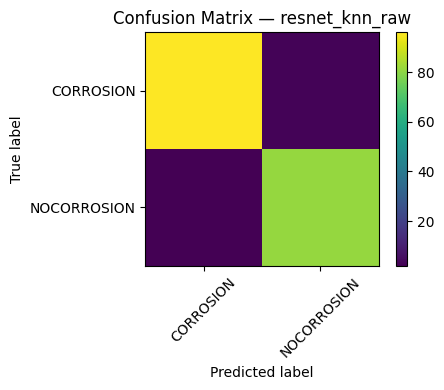

In [51]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_knn, interpolation="nearest")
plt.title(f"Confusion Matrix — {knn_best_name}")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

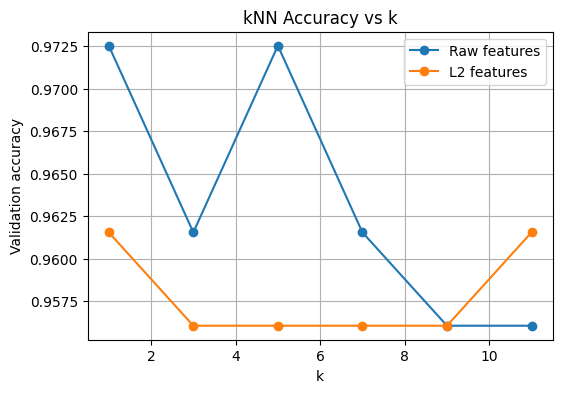

In [52]:
raw_accs = [r["val_acc"] for r in knn_raw_results]
l2_accs  = [r["val_acc"] for r in knn_l2_results]

plt.figure(figsize=(6, 4))
plt.plot(k_values, raw_accs, marker="o", label="Raw features")
plt.plot(k_values, l2_accs, marker="o", label="L2 features")
plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.title("kNN Accuracy vs k")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
knn_results = {
    "raw_results": knn_raw_results,
    "l2_results": knn_l2_results,
    "best_name": knn_best_name,
    "best_feature_type": knn_best_features,
    "best_k": knn_best_result["k"],
    "best_val_acc": knn_best_result["val_acc"]
}

torch.save(knn_results, "knn_results.pt")
print("Saved kNN results.")

Saved kNN results.


### short interpretation

kNN measures local neighborhood structure in the embedding space.

Presults:

- **raw features outperform regularized feature**


next step:
- prototype classifier on the same embeddings

## Section 5 — Prototype Classifier on ResNet Features

use a prototype classifier tp assign samples to the class whose prototype
is closest.

compare:
1. raw ResNet features
2. L2-normalized ResNet features

In [54]:
def compute_class_prototypes(Z, y, num_classes):
    """
    Z: torch.Tensor of shape [N, D]
    y: torch.Tensor of shape [N]
    Returns:
        prototypes: torch.Tensor of shape [C, D]
    """
    prototypes = []

    for class_idx in range(num_classes):
        class_mask = (y == class_idx)
        class_feats = Z[class_mask]
        proto = class_feats.mean(dim=0)
        prototypes.append(proto)

    prototypes = torch.stack(prototypes, dim=0)
    return prototypes

In [55]:
def predict_by_euclidean(Z_query, prototypes):
    """
    Predict class by nearest Euclidean prototype.
    Returns:
        preds: [N]
        dists: [N, C]
    """
    dists = torch.cdist(Z_query, prototypes) 
    preds = torch.argmin(dists, dim=1)
    return preds, dists


def predict_by_cosine(Z_query, prototypes):
    """
    Predict class by highest cosine similarity.
    Returns:
        preds: [N]
        sims: [N, C]
    """
    sims = Z_query @ prototypes.T         
    preds = torch.argmax(sims, dim=1)
    return preds, sims

In [56]:
proto_resnet_raw = compute_class_prototypes(
    Z_resnet_train,
    y_train,
    NUM_CLASSES
)

print("Raw prototype shape:", proto_resnet_raw.shape)

proto_resnet_l2 = compute_class_prototypes(
    Z_resnet_train_l2,
    y_train,
    NUM_CLASSES
)

# normalize prototypes again for cos scoring
proto_resnet_l2 = l2_normalize_torch(proto_resnet_l2)

print("L2 prototype shape:", proto_resnet_l2.shape)

Raw prototype shape: torch.Size([2, 512])
L2 prototype shape: torch.Size([2, 512])


In [57]:
proto_raw_train_preds, proto_raw_train_dists = predict_by_euclidean(
    Z_resnet_train,
    proto_resnet_raw
)

proto_raw_val_preds, proto_raw_val_dists = predict_by_euclidean(
    Z_resnet_val,
    proto_resnet_raw
)

proto_raw_train_acc = accuracy_score(y_train.numpy(), proto_raw_train_preds.numpy())
proto_raw_val_acc   = accuracy_score(y_val.numpy(), proto_raw_val_preds.numpy())

print(f"Prototype RAW train accuracy: {proto_raw_train_acc:.4f}")
print(f"Prototype RAW val accuracy:   {proto_raw_val_acc:.4f}")


proto_l2_train_preds, proto_l2_train_sims = predict_by_cosine(
    Z_resnet_train_l2,
    proto_resnet_l2
)

proto_l2_val_preds, proto_l2_val_sims = predict_by_cosine(
    Z_resnet_val_l2,
    proto_resnet_l2
)

proto_l2_train_acc = accuracy_score(y_train.numpy(), proto_l2_train_preds.numpy())
proto_l2_val_acc   = accuracy_score(y_val.numpy(), proto_l2_val_preds.numpy())

print(f"Prototype L2 train accuracy: {proto_l2_train_acc:.4f}")
print(f"Prototype L2 val accuracy:   {proto_l2_val_acc:.4f}")

Prototype RAW train accuracy: 0.9937
Prototype RAW val accuracy:   0.9615
Prototype L2 train accuracy: 0.9929
Prototype L2 val accuracy:   0.9560


In [58]:
print("Prototype Comparison")
print(f"RAW val accuracy: {proto_raw_val_acc:.4f}")
print(f"L2  val accuracy: {proto_l2_val_acc:.4f}")

Prototype Comparison
RAW val accuracy: 0.9615
L2  val accuracy: 0.9560


In [59]:
if proto_l2_val_acc >= proto_raw_val_acc:
    proto_best_name = "resnet_prototype_l2"
    proto_best_val_preds = proto_l2_val_preds
    proto_best_val_acc = proto_l2_val_acc
    proto_best_mode = "cosine"
else:
    proto_best_name = "resnet_prototype_raw"
    proto_best_val_preds = proto_raw_val_preds
    proto_best_val_acc = proto_raw_val_acc
    proto_best_mode = "euclidean"

print("Best prototype setup:", proto_best_name)
print("Mode:", proto_best_mode)
print("Best val accuracy:", proto_best_val_acc)

Best prototype setup: resnet_prototype_raw
Mode: euclidean
Best val accuracy: 0.9615384615384616


In [60]:
print(classification_report(
    y_val.numpy(),
    proto_best_val_preds.numpy(),
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   CORROSION       0.97      0.96      0.96        99
 NOCORROSION       0.95      0.96      0.96        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



In [61]:
cm_proto = confusion_matrix(y_val.numpy(), proto_best_val_preds.numpy())
print(cm_proto)

[[95  4]
 [ 3 80]]


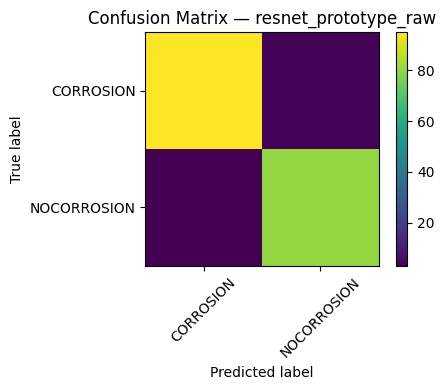

In [62]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_proto, interpolation="nearest")
plt.title(f"Confusion Matrix — {proto_best_name}")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [63]:
prototype_results = {
    "raw_val_acc": proto_raw_val_acc,
    "l2_val_acc": proto_l2_val_acc,
    "best_name": proto_best_name,
    "best_mode": proto_best_mode,
    "best_val_acc": proto_best_val_acc,
    "proto_resnet_raw": proto_resnet_raw,
    "proto_resnet_l2": proto_resnet_l2
}

torch.save(prototype_results, "prototype_results.pt")
print("Saved prototype results.")

Saved prototype results.


### short interpretation


result
- Best feature prototypesetup: resnet_raw
- Mode: euclidean
- val accuracy: 0.962

## Section 6 — ResNet Comparison Summary

summarize the performance of the ResNet18:

1. Direct supervised classifier
2. Linear probe
3. kNN
4. Prototype classifier

In [64]:
resnet_summary = {
    "feature_source": best_supervised_name,
    "fc_only_val_acc": best_val_acc_fc,
    "layer4_val_acc": best_val_acc_l4,
    "linear_probe_best_name": lp_best_name,
    "linear_probe_val_acc": lp_best_val_acc,
    "knn_best_name": knn_best_name,
    "knn_best_k": knn_best_result["k"],
    "knn_val_acc": knn_best_val_acc,
    "prototype_best_name": proto_best_name,
    "prototype_mode": proto_best_mode,
    "prototype_val_acc": proto_best_val_acc
}

resnet_summary

{'feature_source': 'resnet18_layer4',
 'fc_only_val_acc': 0.9395604395604396,
 'layer4_val_acc': 0.967032967032967,
 'linear_probe_best_name': 'resnet_linear_probe_l2',
 'linear_probe_val_acc': 0.9560439560439561,
 'knn_best_name': 'resnet_knn_raw',
 'knn_best_k': 1,
 'knn_val_acc': 0.9725274725274725,
 'prototype_best_name': 'resnet_prototype_raw',
 'prototype_mode': 'euclidean',
 'prototype_val_acc': 0.9615384615384616}

In [65]:
print("ResNet Baseline Summary")
print()
print(f"Feature source model:        {resnet_summary['feature_source']}")
print(f"FC only classifier val acc:  {resnet_summary['fc_only_val_acc']:.4f}")
print(f"Layer4 classifier val acc:   {resnet_summary['layer4_val_acc']:.4f}")
print(f"Best linear probe:           {resnet_summary['linear_probe_best_name']}")
print(f"Linear probe val acc:        {resnet_summary['linear_probe_val_acc']:.4f}")
print(f"Best kNN:                    {resnet_summary['knn_best_name']}")
print(f"Best k:                  {resnet_summary['knn_best_k']}")
print(f"kNN val acc:                 {resnet_summary['knn_val_acc']:.4f}")
print(f"Best prototype:              {resnet_summary['prototype_best_name']}")
print(f"Prototype mode:              {resnet_summary['prototype_mode']}")
print(f"Prototype val acc:           {resnet_summary['prototype_val_acc']:.4f}")

ResNet Baseline Summary

Feature source model:        resnet18_layer4
FC only classifier val acc:  0.9396
Layer4 classifier val acc:   0.9670
Best linear probe:           resnet_linear_probe_l2
Linear probe val acc:        0.9560
Best kNN:                    resnet_knn_raw
Best k:                  1
kNN val acc:                 0.9725
Best prototype:              resnet_prototype_raw
Prototype mode:              euclidean
Prototype val acc:           0.9615


In [66]:
import pandas as pd

resnet_results_df = pd.DataFrame([
    {
        "Method": "ResNet18 FC-only classifier",
        "Feature Space": "classifier logits",
        "Val Accuracy": best_val_acc_fc
    },
    {
        "Method": "ResNet18 layer4 classifier",
        "Feature Space": "classifier logits",
        "Val Accuracy": best_val_acc_l4
    },
    {
        "Method": "Linear probe",
        "Feature Space": lp_best_name,
        "Val Accuracy": lp_best_val_acc
    },
    {
        "Method": "kNN",
        "Feature Space": f"{knn_best_features}, k={knn_best_result['k']}",
        "Val Accuracy": knn_best_val_acc
    },
    {
        "Method": "Prototype classifier",
        "Feature Space": proto_best_name,
        "Val Accuracy": proto_best_val_acc
    }
])

resnet_results_df

,Method,Feature Space,Val Accuracy
0,ResNet18 FC-only classifier,classifier logits,0.939560
1,ResNet18 layer4 classifier,classifier logits,0.967033
2,Linear probe,resnet_linear_probe_l2,0.956044
3,kNN,"RAW, k=1",0.972527
4,Prototype classifier,resnet_prototype_raw,0.961538


In [67]:
resnet_results_df_sorted = resnet_results_df.sort_values(
    by="Val Accuracy",
    ascending=False
).reset_index(drop=True)

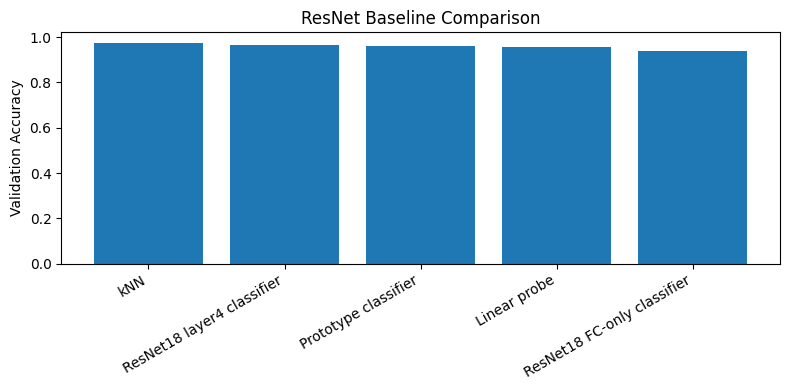

In [68]:
plt.figure(figsize=(8, 4))
plt.bar(resnet_results_df_sorted["Method"], resnet_results_df_sorted["Val Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("ResNet Baseline Comparison")
plt.tight_layout()
plt.show()

In [69]:
torch.save(resnet_summary, "resnet_summary.pt")
resnet_results_df_sorted.to_csv("resnet_results_summary.csv", index=False)

print("Saved:")

Saved:


### shoert interpretation


Result:
- supervised classifier is strong
- extracted features are linearly separable
- local neighborhood structure is strong
- prototype representation works well


choose:

Best ResNet-side method: kNN

Feature space: RAW, k=1

Validation accuracy: 0.9725

## Section 7 — PCA for ResNet Embeddings


- fit PCA on the **training embeddings**

In [70]:
from sklearn.decomposition import PCA

In [71]:
def fit_and_project_pca(X_train, X_val, n_components=2):
    pca = PCA(n_components=n_components)
    X_train_2d = pca.fit_transform(X_train)
    X_val_2d = pca.transform(X_val)
    return pca, X_train_2d, X_val_2d

In [72]:
def plot_embedding_2d(X_2d, y, class_names, title="Embedding"):
    plt.figure(figsize=(6, 5))

    for class_idx, class_name in enumerate(class_names):
        mask = (y == class_idx)
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            label=class_name,
            alpha=0.7
        )

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [73]:
pca_raw, X_train_raw_2d, X_val_raw_2d = fit_and_project_pca(
    X_train_raw,
    X_val_raw,
    n_components=2
)

print("Raw PCA explained variance ratio:", pca_raw.explained_variance_ratio_)
print("Raw PCA total explained variance:", pca_raw.explained_variance_ratio_.sum())

Raw PCA explained variance ratio: [0.2572872  0.03815044]
Raw PCA total explained variance: 0.29543763


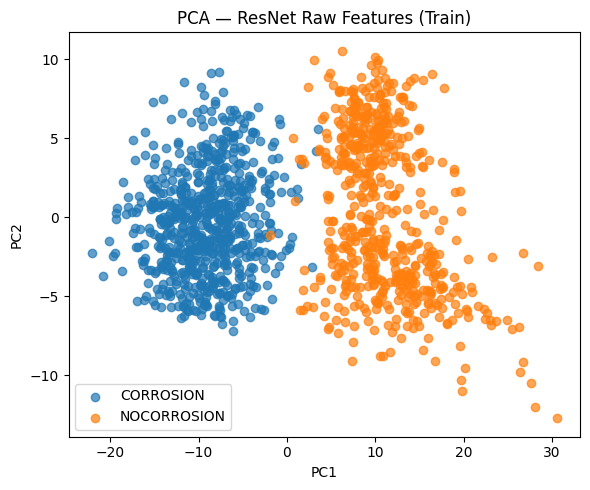

In [74]:
plot_embedding_2d(
    X_train_raw_2d,
    y_train_np,
    CLASS_NAMES,
    title="PCA — ResNet Raw Features (Train)"
)

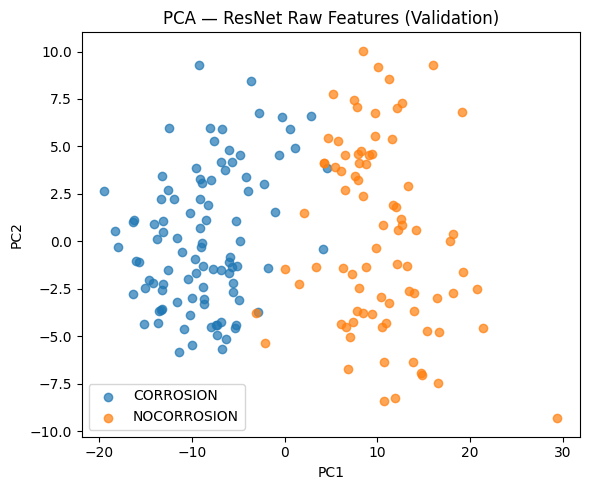

In [75]:
plot_embedding_2d(
    X_val_raw_2d,
    y_val_np,
    CLASS_NAMES,
    title="PCA — ResNet Raw Features (Validation)"
)

In [76]:
pca_l2, X_train_l2_2d, X_val_l2_2d = fit_and_project_pca(
    X_train_l2,
    X_val_l2,
    n_components=2
)

print("L2 PCA explained variance ratio:", pca_l2.explained_variance_ratio_)
print("L2 PCA total explained variance:", pca_l2.explained_variance_ratio_.sum())

L2 PCA explained variance ratio: [0.24404466 0.03950415]
L2 PCA total explained variance: 0.2835488


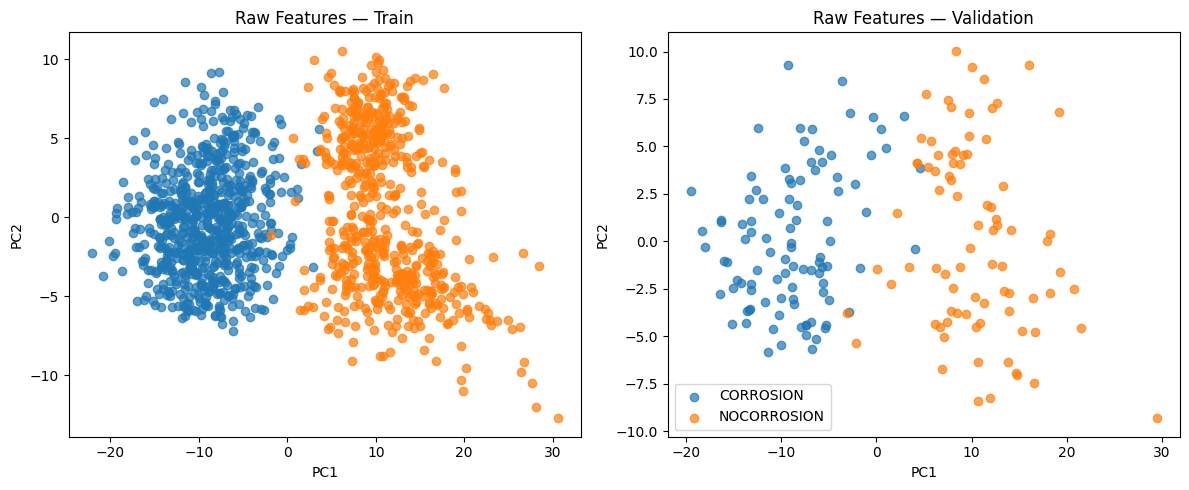

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for class_idx, class_name in enumerate(CLASS_NAMES):
    mask_train = (y_train_np == class_idx)
    axes[0].scatter(
        X_train_raw_2d[mask_train, 0],
        X_train_raw_2d[mask_train, 1],
        label=class_name,
        alpha=0.7
    )

    mask_val = (y_val_np == class_idx)
    axes[1].scatter(
        X_val_raw_2d[mask_val, 0],
        X_val_raw_2d[mask_val, 1],
        label=class_name,
        alpha=0.7
    )

axes[0].set_title("Raw Features — Train")
axes[1].set_title("Raw Features — Validation")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

axes[1].legend()
plt.tight_layout()
plt.show()

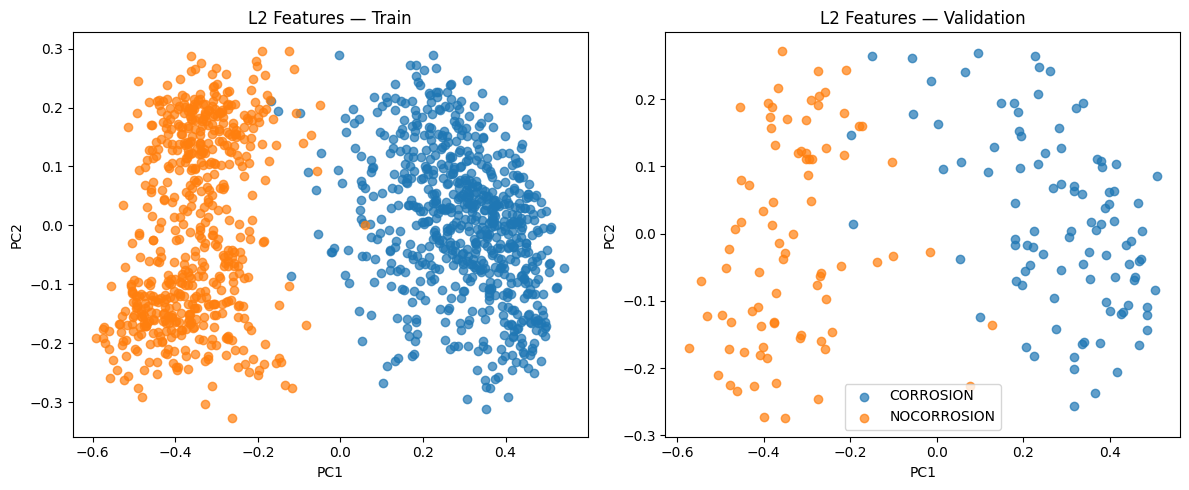

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for class_idx, class_name in enumerate(CLASS_NAMES):
    mask_train = (y_train_np == class_idx)
    axes[0].scatter(
        X_train_l2_2d[mask_train, 0],
        X_train_l2_2d[mask_train, 1],
        label=class_name,
        alpha=0.7
    )

    mask_val = (y_val_np == class_idx)
    axes[1].scatter(
        X_val_l2_2d[mask_val, 0],
        X_val_l2_2d[mask_val, 1],
        label=class_name,
        alpha=0.7
    )

axes[0].set_title("L2 Features — Train")
axes[1].set_title("L2 Features — Validation")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

axes[1].legend()
plt.tight_layout()
plt.show()

In [79]:
pca_outputs = {
    "pca_raw_explained_variance_ratio": pca_raw.explained_variance_ratio_,
    "pca_l2_explained_variance_ratio": pca_l2.explained_variance_ratio_,
    "X_train_raw_2d": X_train_raw_2d,
    "X_val_raw_2d": X_val_raw_2d,
    "X_train_l2_2d": X_train_l2_2d,
    "X_val_l2_2d": X_val_l2_2d
}

torch.save(pca_outputs, "resnet_pca_outputs.pt")
print("Saved PCA outputs.")

Saved PCA outputs.


In [80]:
print("Raw PCA total explained variance:", pca_raw.explained_variance_ratio_.sum())
print("L2  PCA total explained variance:", pca_l2.explained_variance_ratio_.sum())
print("Best linear probe val acc:", lp_best_val_acc)
print("Best kNN val acc:", knn_best_val_acc)
print("Best prototype val acc:", proto_best_val_acc)

Raw PCA total explained variance: 0.29543763
L2  PCA total explained variance: 0.2835488
Best linear probe val acc: 0.9560439560439561
Best kNN val acc: 0.9725274725274725
Best prototype val acc: 0.9615384615384616


### short interpretation

result:

- good PCA separation + good classifier results  
  - embedding is genuinely strong

## Section 8 — Supervised Contrastive Learning
code adapted from: https://github.com/HobbitLong/SupContrast

now train a supcon using the training set.

Important feature spaces:

- `h`: backbone feature before projection head (from resnet18 directly)
- `z`: normalized projection output

In [81]:
import torch.nn.functional as F
from copy import deepcopy

In [82]:
class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()

        base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Remove final FC layer
        self.encoder = nn.Sequential(*list(base_model.children())[:-1])  # output: [B, 512, 1, 1]
        self.feat_dim = base_model.fc.in_features  # 512

        # Projection head
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim)
        )

    def forward(self, x, return_h=False):
        # Backbone feature
        h = self.encoder(x)                    # [B, 512, 1, 1]
        h = torch.flatten(h, start_dim=1)      # [B, 512]

        # Projection feature
        z = self.projector(h)                  # [B, proj_dim]
        z = F.normalize(z, dim=1)              # unit norm projection

        if return_h:
            return h, z
        return z

In [83]:
supcon_model = ResNet18SupCon(proj_dim=128).to(DEVICE)

dummy_x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_h, dummy_z = supcon_model(dummy_x, return_h=True)

print("h shape:", dummy_h.shape)
print("z shape:", dummy_z.shape)

h shape: torch.Size([4, 512])
z shape: torch.Size([4, 128])


In [84]:
# class for computing the loss for supcon
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: [B, V, D]
            B = batch size
            V = 2
            D = embedding dimension
        labels: [B]
        """
        device = features.device
        batch_size = features.shape[0]
        n_views = features.shape[1]

        # Flatten views: [B*V, D]
        features = features.view(batch_size * n_views, -1)
        features = F.normalize(features, dim=1)

        # Similarity matrix
        logits = torch.matmul(features, features.T) / self.temperature

        # stability
        logits_max, _ = torch.max(logits, dim=1, keepdim=True)
        logits = logits - logits_max.detach()

        # repeat labels for each view
        labels = labels.view(-1, 1)
        labels = labels.repeat(n_views, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # mask out self-comparisons
        logits_mask = torch.ones_like(mask) - torch.eye(batch_size * n_views, device=device)
        mask = mask * logits_mask

        # log probabilities
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        # Average
        mask_sum = mask.sum(dim=1)
        mean_log_prob_pos = (mask * log_prob).sum(dim=1) / (mask_sum + 1e-12)

        loss = -mean_log_prob_pos.mean()
        return loss 

In [85]:
def prepare_supcon_batch(view_list, labels, device):
    """
    list is expected to be [view1_batch, view2_batch]
    shape [B, C, H, W]
    """
    x1 = view_list[0].to(device)
    x2 = view_list[1].to(device)
    labels = labels.to(device)
    return x1, x2, labels

In [86]:
def train_supcon_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for view_list, labels in dataloader:
        x1, x2, labels = prepare_supcon_batch(view_list, labels, device)

        optimizer.zero_grad()

        z1 = model(x1)   # [B, D]
        z2 = model(x2)   # [B, D]

        features = torch.stack([z1, z2], dim=1)   # [B, 2, D]
        loss = criterion(features, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

In [87]:
# traiinig function for supcon model
def fit_supcon_model( 
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    checkpoint_path=None
):
    history = {"train_loss": []}

    best_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        train_loss = train_supcon_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        history["train_loss"].append(train_loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | train_loss={train_loss:.4f}")

        if train_loss < best_loss:
            best_loss = train_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_loss

In [88]:
def plot_supcon_history(history, title="SupCon Training"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Epoch 01/20 | train_loss=4.1946
Epoch 02/20 | train_loss=4.1405
Epoch 03/20 | train_loss=4.1396
Epoch 04/20 | train_loss=4.1396
Epoch 05/20 | train_loss=4.1391
Epoch 06/20 | train_loss=4.1388
Epoch 07/20 | train_loss=4.1390
Epoch 08/20 | train_loss=4.1386
Epoch 09/20 | train_loss=4.1385
Epoch 10/20 | train_loss=4.1385
Epoch 11/20 | train_loss=4.1384
Epoch 12/20 | train_loss=4.1384
Epoch 13/20 | train_loss=4.1385
Epoch 14/20 | train_loss=4.1384
Epoch 15/20 | train_loss=4.1384
Epoch 16/20 | train_loss=4.1384
Epoch 17/20 | train_loss=4.1383
Epoch 18/20 | train_loss=4.1384
Epoch 19/20 | train_loss=4.1384
Epoch 20/20 | train_loss=4.1383
Best SupCon train loss: 4.13830016863599


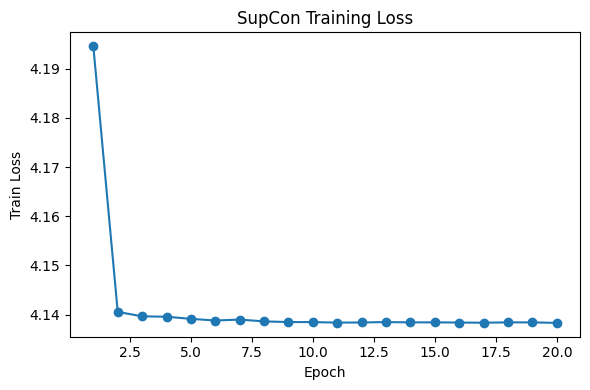

In [89]:
SUPCON_PROJ_DIM = 128 ### 512 --> 218
SUPCON_TEMP = 0.07
SUPCON_EPOCHS = 20
SUPCON_LR = 1e-4

supcon_model = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)

supcon_optimizer = torch.optim.Adam(
    supcon_model.parameters(),
    lr=SUPCON_LR
)

supcon_model, supcon_history, best_supcon_loss = fit_supcon_model(
    model=supcon_model,
    train_loader=train_dl_supcon,
    criterion=supcon_criterion,
    optimizer=supcon_optimizer,
    device=DEVICE,
    epochs=SUPCON_EPOCHS,
    checkpoint_path="supcon_best.pth"
)

print("Best SupCon train loss:", best_supcon_loss)
plot_supcon_history(supcon_history, title="SupCon Training Loss")

In [90]:
supcon_train_summary = {
    "proj_dim": SUPCON_PROJ_DIM,
    "temperature": SUPCON_TEMP,
    "epochs": SUPCON_EPOCHS,
    "learning_rate": SUPCON_LR,
    "best_train_loss": best_supcon_loss
}

torch.save(supcon_train_summary, "supcon_train_summary.pt")
print("Saved SupCon training summary.")

Saved SupCon training summary.


### short interpretation

loss for supcon is only for monitoring

## Section 9 — Extract SupCon Features

extract two feature spaces from the SupCon model:

- `h`: backbone feature before projection head
- `z`: projection output after projection head

In [91]:
def extract_supcon_embeddings(model, dataloader, device):
    model.eval()

    all_h = []
    all_z = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            h, z = model(images, return_h=True)

            all_h.append(h.cpu())
            all_z.append(z.cpu())
            all_labels.append(labels.cpu())

    H = torch.cat(all_h, dim=0)
    Z = torch.cat(all_z, dim=0)
    y = torch.cat(all_labels, dim=0)

    return H, Z, y

In [92]:
# training set
H_supcon_train, Z_supcon_train, y_supcon_train = extract_supcon_embeddings(
    supcon_model,
    train_dl_eval,
    DEVICE
)

print("H_supcon_train shape:", H_supcon_train.shape)
print("Z_supcon_train shape:", Z_supcon_train.shape)
print("y_supcon_train shape:", y_supcon_train.shape)

H_supcon_train shape: torch.Size([1273, 512])
Z_supcon_train shape: torch.Size([1273, 128])
y_supcon_train shape: torch.Size([1273])


In [93]:
# val set
H_supcon_val, Z_supcon_val, y_supcon_val = extract_supcon_embeddings(
    supcon_model,
    val_dl_eval,
    DEVICE
)

print("H_supcon_val shape:", H_supcon_val.shape)
print("Z_supcon_val shape:", Z_supcon_val.shape)
print("y_supcon_val shape:", y_supcon_val.shape)

H_supcon_val shape: torch.Size([182, 512])
Z_supcon_val shape: torch.Size([182, 128])
y_supcon_val shape: torch.Size([182])


In [94]:
# normalized h
H_supcon_train_l2 = l2_normalize_torch(H_supcon_train)
H_supcon_val_l2   = l2_normalize_torch(H_supcon_val)

# normalize z
Z_supcon_train_l2 = l2_normalize_torch(Z_supcon_train)
Z_supcon_val_l2   = l2_normalize_torch(Z_supcon_val)

print("H_supcon_train_l2 shape:", H_supcon_train_l2.shape)
print("Z_supcon_train_l2 shape:", Z_supcon_train_l2.shape)

H_supcon_train_l2 shape: torch.Size([1273, 512])
Z_supcon_train_l2 shape: torch.Size([1273, 128])


In [95]:
X_supcon_h_train_raw = H_supcon_train.numpy()
X_supcon_h_val_raw   = H_supcon_val.numpy()

X_supcon_h_train_l2 = H_supcon_train_l2.numpy()
X_supcon_h_val_l2   = H_supcon_val_l2.numpy()

X_supcon_z_train = Z_supcon_train.numpy()
X_supcon_z_val   = Z_supcon_val.numpy()

X_supcon_z_train_l2 = Z_supcon_train_l2.numpy()
X_supcon_z_val_l2   = Z_supcon_val_l2.numpy()

y_supcon_train_np = y_supcon_train.numpy()
y_supcon_val_np   = y_supcon_val.numpy()

print("SupCon NumPy arrays ready.")

SupCon NumPy arrays ready.


In [96]:
print("ResNet feature dim:", Z_resnet_train.shape[1])
print("SupCon h dim:", H_supcon_train.shape[1])
print("SupCon z dim:", Z_supcon_train.shape[1])

ResNet feature dim: 512
SupCon h dim: 512
SupCon z dim: 128


In [97]:
torch.save(
    {
        "H_supcon_train": H_supcon_train,
        "H_supcon_val": H_supcon_val,
        "H_supcon_train_l2": H_supcon_train_l2,
        "H_supcon_val_l2": H_supcon_val_l2,
        "Z_supcon_train": Z_supcon_train,
        "Z_supcon_val": Z_supcon_val,
        "Z_supcon_train_l2": Z_supcon_train_l2,
        "Z_supcon_val_l2": Z_supcon_val_l2,
        "y_train": y_supcon_train,
        "y_val": y_supcon_val,
    },
    "supcon_features.pt"
)

print("Saved SupCon features to supcon_features.pt")

Saved SupCon features to supcon_features.pt


### short interpretation

Feature spaces now done


#### ResNet features
- `Z_resnet_train`, `Z_resnet_val`
- `Z_resnet_train_l2`, `Z_resnet_val_l2`

#### SupCon backbone features
- `H_supcon_train`, `H_supcon_val`
- `H_supcon_train_l2`, `H_supcon_val_l2`

#### SupCon projection features
- `Z_supcon_train`, `Z_supcon_val`
- `Z_supcon_train_l2`, `Z_supcon_val_l2`

## Section 9 — Linear Probe Comparison Across All Feature Spaces

compare linear probe performance on:

1. ResNet raw features
2. ResNet L2 normalized features
3. SupCon backbone feature `h` (raw)
4. SupCon backbone feature `h` (L2)
5. SupCon projection feature `z`
6. SupCon projection feature `z` (L2)

In [98]:
def run_linear_probe(X_train, y_train, X_val, y_val, max_iter=2000, C=1.0):
    clf = LogisticRegression(
        max_iter=max_iter,
        C=C,
        solver="lbfgs"
    )

    clf.fit(X_train, y_train)

    train_preds = clf.predict(X_train)
    val_preds = clf.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    return clf, train_preds, val_preds, train_acc, val_acc

In [99]:
linear_probe_feature_sets = {
    "resnet_raw": {
        "X_train": X_train_raw,
        "X_val": X_val_raw
    },
    "resnet_l2": {
        "X_train": X_train_l2,
        "X_val": X_val_l2
    },
    "supcon_h_raw": {
        "X_train": X_supcon_h_train_raw,
        "X_val": X_supcon_h_val_raw
    },
    "supcon_h_l2": {
        "X_train": X_supcon_h_train_l2,
        "X_val": X_supcon_h_val_l2
    },
    "supcon_z_raw": {
        "X_train": X_supcon_z_train,
        "X_val": X_supcon_z_val
    },
    "supcon_z_l2": {
        "X_train": X_supcon_z_train_l2,
        "X_val": X_supcon_z_val_l2
    }
}

In [100]:
all_lp_results = []
all_lp_models = {}

for feature_name, feature_data in linear_probe_feature_sets.items():
    clf, train_preds, val_preds, train_acc, val_acc = run_linear_probe(
        feature_data["X_train"],
        y_train_np,
        feature_data["X_val"],
        y_val_np
    )

    all_lp_models[feature_name] = clf

    all_lp_results.append({
        "feature_name": feature_name,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_preds": val_preds
    })

    print(f"{feature_name:15s} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

resnet_raw      | train_acc=1.0000 | val_acc=0.9505
resnet_l2       | train_acc=0.9953 | val_acc=0.9560
supcon_h_raw    | train_acc=0.9961 | val_acc=0.9176
supcon_h_l2     | train_acc=0.8688 | val_acc=0.8681
supcon_z_raw    | train_acc=0.5962 | val_acc=0.5714
supcon_z_l2     | train_acc=0.5962 | val_acc=0.5714


In [101]:
lp_compare_df = pd.DataFrame([
    {
        "Feature Space": r["feature_name"],
        "Train Accuracy": r["train_acc"],
        "Val Accuracy": r["val_acc"]
    }
    for r in all_lp_results
])

lp_compare_df = lp_compare_df.sort_values(
    by="Val Accuracy",
    ascending=False
).reset_index(drop=True)

lp_compare_df

,Feature Space,Train Accuracy,Val Accuracy
0,resnet_l2,0.995287,0.956044
1,resnet_raw,1.000000,0.950549
2,supcon_h_raw,0.996072,0.917582
3,supcon_h_l2,0.868814,0.868132
4,supcon_z_raw,0.596229,0.571429
5,supcon_z_l2,0.596229,0.571429


In [102]:
best_lp_row = lp_compare_df.iloc[0]
best_lp_name = best_lp_row["Feature Space"]
best_lp_val_acc = best_lp_row["Val Accuracy"]

print("Best linear probe feature space:", best_lp_name)
print("Best linear probe val accuracy:", best_lp_val_acc)

Best linear probe feature space: resnet_l2
Best linear probe val accuracy: 0.9560439560439561


In [103]:
best_lp_result = next(r for r in all_lp_results if r["feature_name"] == best_lp_name)
best_lp_val_preds = best_lp_result["val_preds"]

In [104]:
print(classification_report(
    y_val_np,
    best_lp_val_preds,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   CORROSION       0.97      0.95      0.96        99
 NOCORROSION       0.94      0.96      0.95        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



In [105]:
cm_best_lp = confusion_matrix(y_val_np, best_lp_val_preds)
print(cm_best_lp)

[[94  5]
 [ 3 80]]


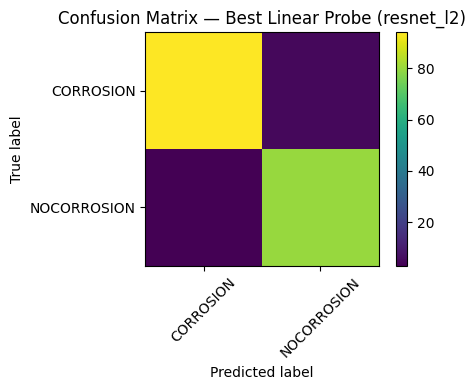

In [106]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_best_lp, interpolation="nearest")
plt.title(f"Confusion Matrix — Best Linear Probe ({best_lp_name})")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

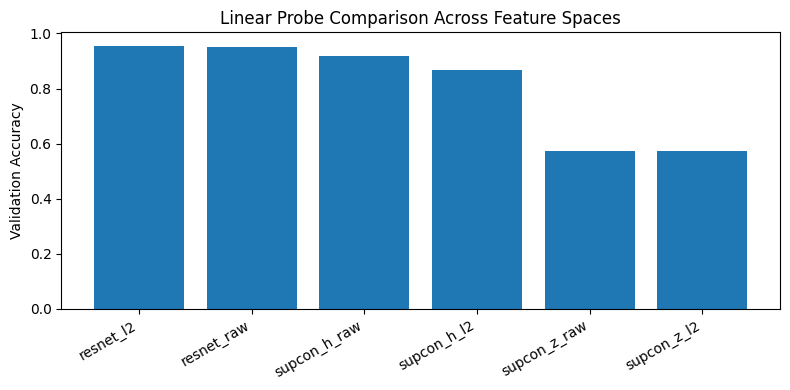

In [107]:
plt.figure(figsize=(8, 4))
plt.bar(lp_compare_df["Feature Space"], lp_compare_df["Val Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Linear Probe Comparison Across Feature Spaces")
plt.tight_layout()
plt.show()

In [108]:
for name in [
    "resnet_raw",
    "resnet_l2",
    "supcon_h_raw",
    "supcon_h_l2",
    "supcon_z_raw",
    "supcon_z_l2"
]:
    row = lp_compare_df[lp_compare_df["Feature Space"] == name]
    if len(row) > 0:
        val_acc = row.iloc[0]["Val Accuracy"]
        print(f"{name:15s} -> {val_acc:.4f}")

resnet_raw      -> 0.9505
resnet_l2       -> 0.9560
supcon_h_raw    -> 0.9176
supcon_h_l2     -> 0.8681
supcon_z_raw    -> 0.5714
supcon_z_l2     -> 0.5714


In [109]:
lp_compare_df.to_csv("linear_probe_all_features.csv", index=False)

torch.save(
    {
        "results_table": lp_compare_df.to_dict(orient="records"),
        "best_feature_space": best_lp_name,
        "best_val_acc": best_lp_val_acc
    },
    "linear_probe_all_features.pt"
)

print("Saved linear probe comparison results.")

Saved linear probe comparison results.


In [110]:
resnet_raw_acc   = lp_compare_df.loc[lp_compare_df["Feature Space"] == "resnet_raw", "Val Accuracy"].values[0]
resnet_l2_acc    = lp_compare_df.loc[lp_compare_df["Feature Space"] == "resnet_l2", "Val Accuracy"].values[0]
supcon_h_raw_acc = lp_compare_df.loc[lp_compare_df["Feature Space"] == "supcon_h_raw", "Val Accuracy"].values[0]
supcon_h_l2_acc  = lp_compare_df.loc[lp_compare_df["Feature Space"] == "supcon_h_l2", "Val Accuracy"].values[0]
supcon_z_raw_acc = lp_compare_df.loc[lp_compare_df["Feature Space"] == "supcon_z_raw", "Val Accuracy"].values[0]
supcon_z_l2_acc  = lp_compare_df.loc[lp_compare_df["Feature Space"] == "supcon_z_l2", "Val Accuracy"].values[0]

print("Summary")
print()
print(f"Best ResNet linear probe:   {max(resnet_raw_acc, resnet_l2_acc):.4f}")
print(f"Best SupCon h linear probe: {max(supcon_h_raw_acc, supcon_h_l2_acc):.4f}")
print(f"Best SupCon z linear probe: {max(supcon_z_raw_acc, supcon_z_l2_acc):.4f}")

Summary

Best ResNet linear probe:   0.9560
Best SupCon h linear probe: 0.9176
Best SupCon z linear probe: 0.5714


### short interpretation


results:

- **ResNet > SupCon h > SupCon z**
  - projection head does not work well with linear method

## Section 10 — kNN Comparison Across All Feature Spaces

compare knn performance on:

1. ResNet raw features
2. ResNet L2 normalized features
3. SupCon backbone feature `h` (raw)
4. SupCon backbone feature `h` (L2)
5. SupCon projection feature `z` (raw)
6. SupCon projection feature `z` (L2)

In [111]:
def run_knn(X_train, y_train, X_val, y_val, k=5, metric="euclidean"):
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric=metric
    )

    knn.fit(X_train, y_train)

    train_preds = knn.predict(X_train)
    val_preds = knn.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    return knn, train_preds, val_preds, train_acc, val_acc

In [112]:
knn_feature_sets = {
    "resnet_raw": {
        "X_train": X_train_raw,
        "X_val": X_val_raw
    },
    "resnet_l2": {
        "X_train": X_train_l2,
        "X_val": X_val_l2
    },
    "supcon_h_raw": {
        "X_train": X_supcon_h_train_raw,
        "X_val": X_supcon_h_val_raw
    },
    "supcon_h_l2": {
        "X_train": X_supcon_h_train_l2,
        "X_val": X_supcon_h_val_l2
    },
    "supcon_z_raw": {
        "X_train": X_supcon_z_train,
        "X_val": X_supcon_z_val
    },
    "supcon_z_l2": {
        "X_train": X_supcon_z_train_l2,
        "X_val": X_supcon_z_val_l2
    }
}

k_values = [1, 3, 5, 7, 9, 11]

In [113]:
all_knn_results = []

for feature_name, feature_data in knn_feature_sets.items():
    for k in k_values:
        _, train_preds, val_preds, train_acc, val_acc = run_knn(
            feature_data["X_train"],
            y_train_np,
            feature_data["X_val"],
            y_val_np,
            k=k,
            metric="euclidean"
        )

        all_knn_results.append({
            "feature_name": feature_name,
            "k": k,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "val_preds": val_preds
        })

        print(f"{feature_name:15s} | k={k:2d} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

resnet_raw      | k= 1 | train_acc=1.0000 | val_acc=0.9725
resnet_raw      | k= 3 | train_acc=0.9976 | val_acc=0.9615
resnet_raw      | k= 5 | train_acc=0.9976 | val_acc=0.9725
resnet_raw      | k= 7 | train_acc=0.9953 | val_acc=0.9615
resnet_raw      | k= 9 | train_acc=0.9937 | val_acc=0.9560
resnet_raw      | k=11 | train_acc=0.9945 | val_acc=0.9560
resnet_l2       | k= 1 | train_acc=1.0000 | val_acc=0.9615
resnet_l2       | k= 3 | train_acc=0.9976 | val_acc=0.9560
resnet_l2       | k= 5 | train_acc=0.9969 | val_acc=0.9560
resnet_l2       | k= 7 | train_acc=0.9976 | val_acc=0.9560
resnet_l2       | k= 9 | train_acc=0.9976 | val_acc=0.9560
resnet_l2       | k=11 | train_acc=0.9953 | val_acc=0.9615
supcon_h_raw    | k= 1 | train_acc=1.0000 | val_acc=0.8462
supcon_h_raw    | k= 3 | train_acc=0.9356 | val_acc=0.8242
supcon_h_raw    | k= 5 | train_acc=0.9183 | val_acc=0.8462
supcon_h_raw    | k= 7 | train_acc=0.9089 | val_acc=0.8352
supcon_h_raw    | k= 9 | train_acc=0.9002 | val_acc=0.81

In [114]:
knn_compare_df = pd.DataFrame([
    {
        "Feature Space": r["feature_name"],
        "k": r["k"],
        "Train Accuracy": r["train_acc"],
        "Val Accuracy": r["val_acc"]
    }
    for r in all_knn_results
])

knn_compare_df.head()

,Feature Space,k,Train Accuracy,Val Accuracy
0,resnet_raw,1,1.000000,0.972527
1,resnet_raw,3,0.997643,0.961538
2,resnet_raw,5,0.997643,0.972527
3,resnet_raw,7,0.995287,0.961538
4,resnet_raw,9,0.993716,0.956044


In [115]:
knn_best_per_feature_df = (
    knn_compare_df
    .sort_values(["Feature Space", "Val Accuracy"], ascending=[True, False])
    .groupby("Feature Space", as_index=False)
    .first()
    .sort_values("Val Accuracy", ascending=False)
    .reset_index(drop=True)
)

knn_best_per_feature_df

,Feature Space,k,Train Accuracy,Val Accuracy
0,resnet_raw,1,1.000000,0.972527
1,resnet_l2,1,1.000000,0.961538
2,supcon_h_l2,3,0.937156,0.868132
3,supcon_h_raw,1,1.000000,0.846154
4,supcon_z_l2,1,1.000000,0.829670
5,supcon_z_raw,1,1.000000,0.829670


In [116]:
best_knn_row = knn_compare_df.sort_values("Val Accuracy", ascending=False).iloc[0]

best_knn_feature = best_knn_row["Feature Space"]
best_knn_k = int(best_knn_row["k"])
best_knn_val_acc = best_knn_row["Val Accuracy"]

print("Best overall kNN feature space:", best_knn_feature)
print("Best overall k:", best_knn_k)
print("Best overall val accuracy:", best_knn_val_acc)

Best overall kNN feature space: resnet_raw
Best overall k: 1
Best overall val accuracy: 0.9725274725274725


In [117]:
best_knn_result = next(
    r for r in all_knn_results
    if r["feature_name"] == best_knn_feature and r["k"] == best_knn_k
)

best_knn_val_preds = best_knn_result["val_preds"]

In [118]:
print(classification_report(
    y_val_np,
    best_knn_val_preds,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   CORROSION       0.98      0.97      0.97        99
 NOCORROSION       0.96      0.98      0.97        83

    accuracy                           0.97       182
   macro avg       0.97      0.97      0.97       182
weighted avg       0.97      0.97      0.97       182



In [119]:
cm_best_knn = confusion_matrix(y_val_np, best_knn_val_preds)
print(cm_best_knn)

[[96  3]
 [ 2 81]]


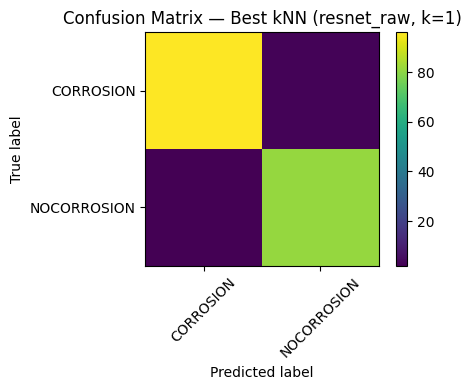

In [120]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_best_knn, interpolation="nearest")
plt.title(f"Confusion Matrix — Best kNN ({best_knn_feature}, k={best_knn_k})")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

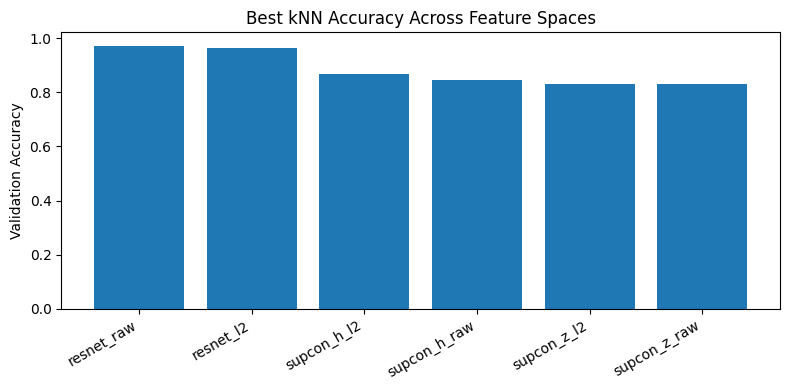

In [121]:
plt.figure(figsize=(8, 4))
plt.bar(knn_best_per_feature_df["Feature Space"], knn_best_per_feature_df["Val Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Best kNN Accuracy Across Feature Spaces")
plt.tight_layout()
plt.show()

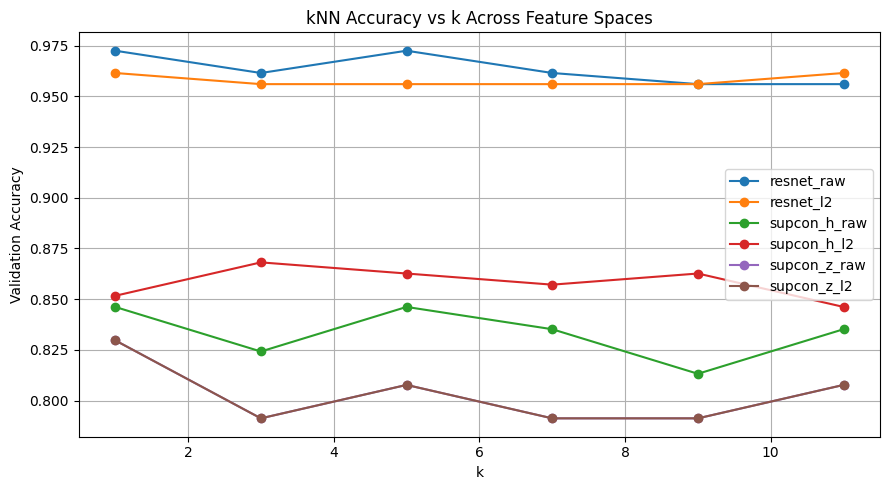

In [122]:
plt.figure(figsize=(9, 5))

for feature_name in knn_feature_sets.keys():
    subset = knn_compare_df[knn_compare_df["Feature Space"] == feature_name].sort_values("k")
    plt.plot(subset["k"], subset["Val Accuracy"], marker="o", label=feature_name)

plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("kNN Accuracy vs k Across Feature Spaces")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
for feature_name in [
    "resnet_raw",
    "resnet_l2",
    "supcon_h_raw",
    "supcon_h_l2",
    "supcon_z_raw",
    "supcon_z_l2"
]:
    row = knn_best_per_feature_df[knn_best_per_feature_df["Feature Space"] == feature_name]
    if len(row) > 0:
        best_k = int(row.iloc[0]["k"])
        best_acc = row.iloc[0]["Val Accuracy"]
        print(f"{feature_name:15s} -> best k={best_k:2d}, val_acc={best_acc:.4f}")

resnet_raw      -> best k= 1, val_acc=0.9725
resnet_l2       -> best k= 1, val_acc=0.9615
supcon_h_raw    -> best k= 1, val_acc=0.8462
supcon_h_l2     -> best k= 3, val_acc=0.8681
supcon_z_raw    -> best k= 1, val_acc=0.8297
supcon_z_l2     -> best k= 1, val_acc=0.8297


In [124]:
knn_best_per_feature_df.to_csv("knn_best_per_feature.csv", index=False)
knn_compare_df.to_csv("knn_all_features_all_k.csv", index=False)

torch.save(
    {
        "all_results": knn_compare_df.to_dict(orient="records"),
        "best_per_feature": knn_best_per_feature_df.to_dict(orient="records"),
        "best_feature_space": best_knn_feature,
        "best_k": best_knn_k,
        "best_val_acc": best_knn_val_acc
    },
    "knn_all_features.pt"
)

print("Saved kNN comparison results.")

Saved kNN comparison results.


In [125]:
def get_best_knn_acc(feature_name):
    row = knn_best_per_feature_df[knn_best_per_feature_df["Feature Space"] == feature_name]
    return float(row.iloc[0]["Val Accuracy"])

print("kNN Summary")
print()
print(f"Best ResNet kNN:   {max(get_best_knn_acc('resnet_raw'), get_best_knn_acc('resnet_l2')):.4f}")
print(f"Best SupCon h kNN: {max(get_best_knn_acc('supcon_h_raw'), get_best_knn_acc('supcon_h_l2')):.4f}")
print(f"Best SupCon z kNN: {max(get_best_knn_acc('supcon_z_raw'), get_best_knn_acc('supcon_z_l2')):.4f}")

kNN Summary

Best ResNet kNN:   0.9725
Best SupCon h kNN: 0.8681
Best SupCon z kNN: 0.8297


### short interpretation

kNN tests local structure

Typical outcomes:

- **ResNet > SupCon h > SupCon z**
  - projection space has weak local geometry

## Section 11 — Prototype Comparison Across All Feature Spaces

compare prototype on:

1. ResNet raw features
2. ResNet L2 normalized features
3. SupCon backbone feature `h` (raw)
4. SupCon backbone feature `h` (L2)
5. SupCon projection feature `z` (raw)
6. SupCon projection feature `z` (L2)

In [126]:
def compute_class_prototypes(Z, y, num_classes):
    prototypes = []

    for class_idx in range(num_classes):
        class_mask = (y == class_idx)
        class_feats = Z[class_mask]
        proto = class_feats.mean(dim=0)
        prototypes.append(proto)

    prototypes = torch.stack(prototypes, dim=0)
    return prototypes


def predict_by_euclidean(Z_query, prototypes):
    dists = torch.cdist(Z_query, prototypes)   # smaller better
    preds = torch.argmin(dists, dim=1)
    return preds, dists


def predict_by_cosine(Z_query, prototypes):
    sims = Z_query @ prototypes.T              # larger better
    preds = torch.argmax(sims, dim=1)
    return preds, sims

In [127]:
prototype_feature_sets = {
    "resnet_raw": {
        "Z_train": Z_resnet_train,
        "Z_val": Z_resnet_val,
        "mode": "euclidean"
    },
    "resnet_l2": {
        "Z_train": Z_resnet_train_l2,
        "Z_val": Z_resnet_val_l2,
        "mode": "cosine"
    },
    "supcon_h_raw": {
        "Z_train": H_supcon_train,
        "Z_val": H_supcon_val,
        "mode": "euclidean"
    },
    "supcon_h_l2": {
        "Z_train": H_supcon_train_l2,
        "Z_val": H_supcon_val_l2,
        "mode": "cosine"
    },
    "supcon_z_raw": {
        "Z_train": Z_supcon_train,
        "Z_val": Z_supcon_val,
        "mode": "euclidean"
    },
    "supcon_z_l2": {
        "Z_train": Z_supcon_train_l2,
        "Z_val": Z_supcon_val_l2,
        "mode": "cosine"
    }
}

In [128]:
all_proto_results = []
all_prototypes = {}

for feature_name, feature_data in prototype_feature_sets.items():
    Z_train_t = feature_data["Z_train"]
    Z_val_t = feature_data["Z_val"]
    mode = feature_data["mode"]

    prototypes = compute_class_prototypes(Z_train_t, y_train, NUM_CLASSES)

    if mode == "cosine":
        prototypes = l2_normalize_torch(prototypes)
        train_preds, train_scores = predict_by_cosine(Z_train_t, prototypes)
        val_preds, val_scores = predict_by_cosine(Z_val_t, prototypes)
    elif mode == "euclidean":
        train_preds, train_scores = predict_by_euclidean(Z_train_t, prototypes)
        val_preds, val_scores = predict_by_euclidean(Z_val_t, prototypes)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
    val_acc = accuracy_score(y_val.numpy(), val_preds.numpy())

    all_prototypes[feature_name] = prototypes

    all_proto_results.append({
        "feature_name": feature_name,
        "mode": mode,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_preds": val_preds,
        "prototypes": prototypes
    })

    print(f"{feature_name:15s} | mode={mode:9s} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

resnet_raw      | mode=euclidean | train_acc=0.9937 | val_acc=0.9615
resnet_l2       | mode=cosine    | train_acc=0.9929 | val_acc=0.9560
supcon_h_raw    | mode=euclidean | train_acc=0.8201 | val_acc=0.8077
supcon_h_l2     | mode=cosine    | train_acc=0.8115 | val_acc=0.8077
supcon_z_raw    | mode=euclidean | train_acc=0.7785 | val_acc=0.7802
supcon_z_l2     | mode=cosine    | train_acc=0.7785 | val_acc=0.7802


In [129]:
proto_compare_df = pd.DataFrame([
    {
        "Feature Space": r["feature_name"],
        "Mode": r["mode"],
        "Train Accuracy": r["train_acc"],
        "Val Accuracy": r["val_acc"]
    }
    for r in all_proto_results
])

proto_compare_df = proto_compare_df.sort_values(
    by="Val Accuracy",
    ascending=False
).reset_index(drop=True)

proto_compare_df

,Feature Space,Mode,Train Accuracy,Val Accuracy
0,resnet_raw,euclidean,0.993716,0.961538
1,resnet_l2,cosine,0.992930,0.956044
2,supcon_h_raw,euclidean,0.820110,0.807692
3,supcon_h_l2,cosine,0.811469,0.807692
4,supcon_z_raw,euclidean,0.778476,0.780220
5,supcon_z_l2,cosine,0.778476,0.780220


In [130]:
best_proto_row = proto_compare_df.iloc[0]

best_proto_feature = best_proto_row["Feature Space"]
best_proto_mode = best_proto_row["Mode"]
best_proto_val_acc = best_proto_row["Val Accuracy"]

print("Best prototype feature space:", best_proto_feature)
print("Best prototype mode:", best_proto_mode)
print("Best prototype val accuracy:", best_proto_val_acc)

Best prototype feature space: resnet_raw
Best prototype mode: euclidean
Best prototype val accuracy: 0.9615384615384616


In [131]:
best_proto_result = next(
    r for r in all_proto_results
    if r["feature_name"] == best_proto_feature
)

best_proto_val_preds = best_proto_result["val_preds"]
best_proto_tensor = best_proto_result["prototypes"]

In [132]:
print(classification_report(
    y_val_np,
    best_proto_val_preds.numpy(),
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   CORROSION       0.97      0.96      0.96        99
 NOCORROSION       0.95      0.96      0.96        83

    accuracy                           0.96       182
   macro avg       0.96      0.96      0.96       182
weighted avg       0.96      0.96      0.96       182



In [133]:
cm_best_proto = confusion_matrix(y_val_np, best_proto_val_preds.numpy())
print(cm_best_proto)

[[95  4]
 [ 3 80]]


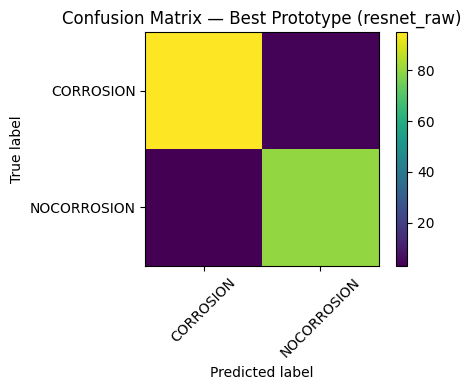

In [134]:
plt.figure(figsize=(5, 4))
plt.imshow(cm_best_proto, interpolation="nearest")
plt.title(f"Confusion Matrix — Best Prototype ({best_proto_feature})")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

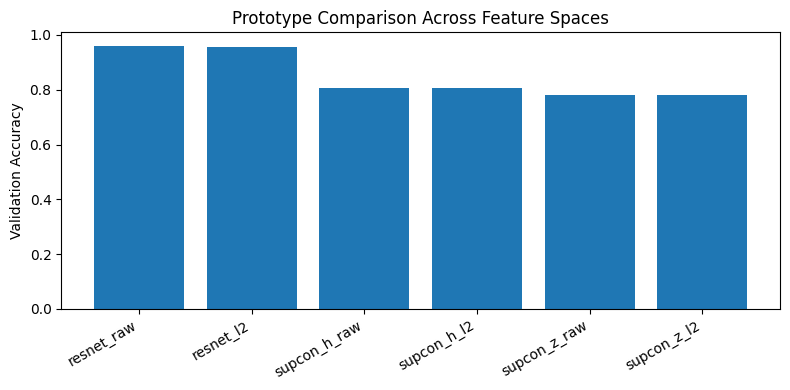

In [135]:
plt.figure(figsize=(8, 4))
plt.bar(proto_compare_df["Feature Space"], proto_compare_df["Val Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Prototype Comparison Across Feature Spaces")
plt.tight_layout()
plt.show()

In [136]:
for feature_name in [
    "resnet_raw",
    "resnet_l2",
    "supcon_h_raw",
    "supcon_h_l2",
    "supcon_z_raw",
    "supcon_z_l2"
]:
    row = proto_compare_df[proto_compare_df["Feature Space"] == feature_name]
    if len(row) > 0:
        mode = row.iloc[0]["Mode"]
        val_acc = row.iloc[0]["Val Accuracy"]
        print(f"{feature_name:15s} -> mode={mode:9s}, val_acc={val_acc:.4f}")

resnet_raw      -> mode=euclidean, val_acc=0.9615
resnet_l2       -> mode=cosine   , val_acc=0.9560
supcon_h_raw    -> mode=euclidean, val_acc=0.8077
supcon_h_l2     -> mode=cosine   , val_acc=0.8077
supcon_z_raw    -> mode=euclidean, val_acc=0.7802
supcon_z_l2     -> mode=cosine   , val_acc=0.7802


In [137]:
proto_compare_df.to_csv("prototype_all_features.csv", index=False)

torch.save(
    {
        "results_table": proto_compare_df.to_dict(orient="records"),
        "best_feature_space": best_proto_feature,
        "best_mode": best_proto_mode,
        "best_val_acc": best_proto_val_acc
    },
    "prototype_all_features.pt"
)

print("Saved prototype comparison results.")

Saved prototype comparison results.


In [138]:
def get_proto_acc(feature_name):
    row = proto_compare_df[proto_compare_df["Feature Space"] == feature_name]
    return float(row.iloc[0]["Val Accuracy"])

print("Prototype Summary")
print()
print(f"Best ResNet prototype:   {max(get_proto_acc('resnet_raw'), get_proto_acc('resnet_l2')):.4f}")
print(f"Best SupCon h prototype: {max(get_proto_acc('supcon_h_raw'), get_proto_acc('supcon_h_l2')):.4f}")
print(f"Best SupCon z prototype: {max(get_proto_acc('supcon_z_raw'), get_proto_acc('supcon_z_l2')):.4f}")

Prototype Summary

Best ResNet prototype:   0.9615
Best SupCon h prototype: 0.8077
Best SupCon z prototype: 0.7802


### short interpretation



Typical outcomes:

- **ResNet > SupCon h > SupCon z**
  - projection space hurts class-center structure

## Section 12 — Final Comparison Across All Methods


Methods included:
1. Supervised classifier baselines
2. Linear probe
3. kNN
4. Prototype classifier

Feature families included:
- ResNet supervised baseline
- SupCon backbone feature `h`
- SupCon projection feature `z`

In [139]:
lp_best_rows = lp_compare_df.copy()
lp_best_rows["Method"] = "Linear Probe"
lp_best_rows = lp_best_rows.rename(columns={"Feature Space": "FeatureFamily"})
lp_best_rows = lp_best_rows[["Method", "FeatureFamily", "Train Accuracy", "Val Accuracy"]]

lp_best_rows.head()

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,Linear Probe,resnet_l2,0.995287,0.956044
1,Linear Probe,resnet_raw,1.000000,0.950549
2,Linear Probe,supcon_h_raw,0.996072,0.917582
3,Linear Probe,supcon_h_l2,0.868814,0.868132
4,Linear Probe,supcon_z_raw,0.596229,0.571429


In [140]:
knn_summary_rows = knn_best_per_feature_df.copy()
knn_summary_rows["Method"] = "kNN"
knn_summary_rows["FeatureFamily"] = knn_summary_rows["Feature Space"] + " | k=" + knn_summary_rows["k"].astype(str)
knn_summary_rows = knn_summary_rows[["Method", "FeatureFamily", "Train Accuracy", "Val Accuracy"]]

knn_summary_rows.head()

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,kNN,resnet_raw | k=1,1.000000,0.972527
1,kNN,resnet_l2 | k=1,1.000000,0.961538
2,kNN,supcon_h_l2 | k=3,0.937156,0.868132
3,kNN,supcon_h_raw | k=1,1.000000,0.846154
4,kNN,supcon_z_l2 | k=1,1.000000,0.829670


In [141]:
proto_summary_rows = proto_compare_df.copy()
proto_summary_rows["Method"] = "Prototype"
proto_summary_rows["FeatureFamily"] = proto_summary_rows["Feature Space"] + " | " + proto_compare_df["Mode"]
proto_summary_rows = proto_summary_rows[["Method", "FeatureFamily", "Train Accuracy", "Val Accuracy"]]

proto_summary_rows.head()

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,Prototype,resnet_raw | euclidean,0.993716,0.961538
1,Prototype,resnet_l2 | cosine,0.992930,0.956044
2,Prototype,supcon_h_raw | euclidean,0.820110,0.807692
3,Prototype,supcon_h_l2 | cosine,0.811469,0.807692
4,Prototype,supcon_z_raw | euclidean,0.778476,0.780220


In [142]:
supervised_summary_rows = pd.DataFrame([
    {
        "Method": "Supervised Classifier",
        "FeatureFamily": "resnet18_fc_only | logits",
        "Train Accuracy": np.nan,
        "Val Accuracy": best_val_acc_fc
    },
    {
        "Method": "Supervised Classifier",
        "FeatureFamily": "resnet18_layer4 | logits",
        "Train Accuracy": np.nan,
        "Val Accuracy": best_val_acc_l4
    }
])

supervised_summary_rows

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,Supervised Classifier,resnet18_fc_only | logits,NaN,0.939560
1,Supervised Classifier,resnet18_layer4 | logits,NaN,0.967033


In [143]:
all_results_df = pd.concat([
    supervised_summary_rows,
    lp_best_rows,
    knn_summary_rows,
    proto_summary_rows
], ignore_index=True)

all_results_df

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,Supervised Classifier,resnet18_fc_only | logits,NaN,0.939560
1,Supervised Classifier,resnet18_layer4 | logits,NaN,0.967033
2,Linear Probe,resnet_l2,0.995287,0.956044
3,Linear Probe,resnet_raw,1.000000,0.950549
4,Linear Probe,supcon_h_raw,0.996072,0.917582
5,Linear Probe,supcon_h_l2,0.868814,0.868132
6,Linear Probe,supcon_z_raw,0.596229,0.571429
7,Linear Probe,supcon_z_l2,0.596229,0.571429
8,kNN,resnet_raw | k=1,1.000000,0.972527
9,kNN,resnet_l2 | k=1,1.000000,0.961538


In [144]:
all_results_df_sorted = all_results_df.sort_values(
    by="Val Accuracy",
    ascending=False
).reset_index(drop=True)

all_results_df_sorted

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,kNN,resnet_raw | k=1,1.000000,0.972527
1,Supervised Classifier,resnet18_layer4 | logits,NaN,0.967033
2,kNN,resnet_l2 | k=1,1.000000,0.961538
3,Prototype,resnet_raw | euclidean,0.993716,0.961538
4,Linear Probe,resnet_l2,0.995287,0.956044
5,Prototype,resnet_l2 | cosine,0.992930,0.956044
6,Linear Probe,resnet_raw,1.000000,0.950549
7,Supervised Classifier,resnet18_fc_only | logits,NaN,0.939560
8,Linear Probe,supcon_h_raw,0.996072,0.917582
9,kNN,supcon_h_l2 | k=3,0.937156,0.868132


In [145]:
all_results_df_sorted.head(15)

,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,kNN,resnet_raw | k=1,1.000000,0.972527
1,Supervised Classifier,resnet18_layer4 | logits,NaN,0.967033
2,kNN,resnet_l2 | k=1,1.000000,0.961538
3,Prototype,resnet_raw | euclidean,0.993716,0.961538
4,Linear Probe,resnet_l2,0.995287,0.956044
5,Prototype,resnet_l2 | cosine,0.992930,0.956044
6,Linear Probe,resnet_raw,1.000000,0.950549
7,Supervised Classifier,resnet18_fc_only | logits,NaN,0.939560
8,Linear Probe,supcon_h_raw,0.996072,0.917582
9,kNN,supcon_h_l2 | k=3,0.937156,0.868132


In [146]:
def infer_main_family(feature_name):
    if "resnet" in feature_name:
        return "ResNet"
    elif "supcon_h" in feature_name:
        return "SupCon-h"
    elif "supcon_z" in feature_name:
        return "SupCon-z"
    else:
        return "Other"

all_results_df_sorted["MainFamily"] = all_results_df_sorted["FeatureFamily"].apply(infer_main_family)
all_results_df_sorted.head()

,Method,FeatureFamily,Train Accuracy,Val Accuracy,MainFamily
0,kNN,resnet_raw | k=1,1.000000,0.972527,ResNet
1,Supervised Classifier,resnet18_layer4 | logits,NaN,0.967033,ResNet
2,kNN,resnet_l2 | k=1,1.000000,0.961538,ResNet
3,Prototype,resnet_raw | euclidean,0.993716,0.961538,ResNet
4,Linear Probe,resnet_l2,0.995287,0.956044,ResNet


In [147]:
best_per_family_df = (
    all_results_df_sorted
    .groupby("MainFamily", as_index=False)
    .first()
    .sort_values("Val Accuracy", ascending=False)
    .reset_index(drop=True)
)

best_per_family_df

,MainFamily,Method,FeatureFamily,Train Accuracy,Val Accuracy
0,ResNet,kNN,resnet_raw | k=1,1.000000,0.972527
1,SupCon-h,Linear Probe,supcon_h_raw,0.996072,0.917582
2,SupCon-z,kNN,supcon_z_l2 | k=1,1.000000,0.829670


In [148]:
print("Best Result Per Main Method")
for _, row in best_per_family_df.iterrows():
    print(f"{row['MainFamily']:10s} | {row['Method']:22s} | {row['FeatureFamily']:30s} | val_acc={row['Val Accuracy']:.4f}")

Best Result Per Main Method
ResNet     | kNN                    | resnet_raw | k=1               | val_acc=0.9725
SupCon-h   | Linear Probe           | supcon_h_raw                   | val_acc=0.9176
SupCon-z   | kNN                    | supcon_z_l2 | k=1              | val_acc=0.8297


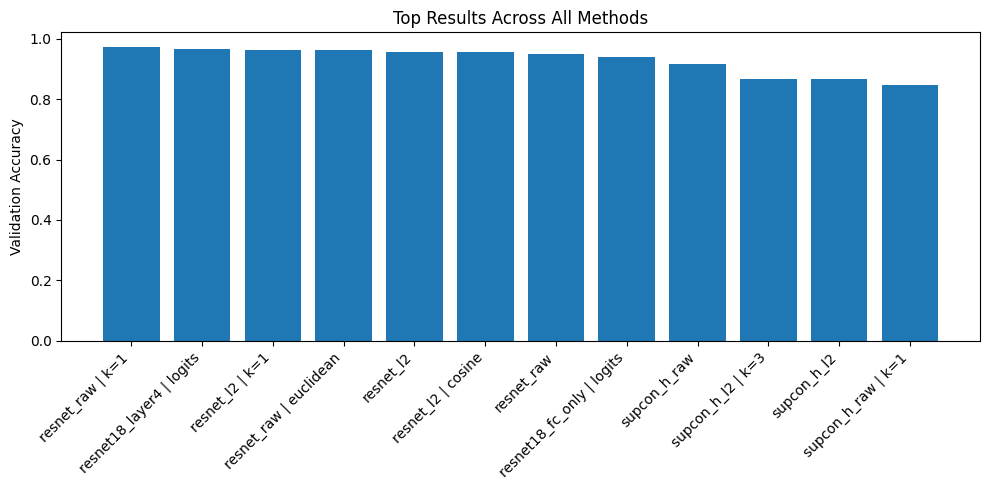

In [149]:
top_n = min(12, len(all_results_df_sorted))
top_df = all_results_df_sorted.head(top_n)

plt.figure(figsize=(10, 5))
plt.bar(top_df["FeatureFamily"], top_df["Val Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Top Results Across All Methods")
plt.tight_layout()
plt.show()

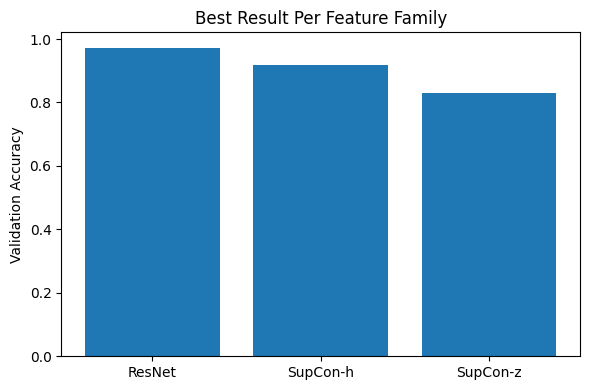

In [150]:
plt.figure(figsize=(6, 4))
plt.bar(best_per_family_df["MainFamily"], best_per_family_df["Val Accuracy"])
plt.ylabel("Validation Accuracy")
plt.title("Best Result Per Feature Family")
plt.tight_layout()
plt.show()

In [151]:
best_resnet_acc = best_per_family_df.loc[best_per_family_df["MainFamily"] == "ResNet", "Val Accuracy"].values[0]
best_supcon_h_acc = best_per_family_df.loc[best_per_family_df["MainFamily"] == "SupCon-h", "Val Accuracy"].values[0]
best_supcon_z_acc = best_per_family_df.loc[best_per_family_df["MainFamily"] == "SupCon-z", "Val Accuracy"].values[0]

print("Best ResNet result:   ", round(float(best_resnet_acc), 4))
print("Best SupCon-h result: ", round(float(best_supcon_h_acc), 4))
print("Best SupCon-z result: ", round(float(best_supcon_z_acc), 4))

Best ResNet result:    0.9725
Best SupCon-h result:  0.9176
Best SupCon-z result:  0.8297


In [152]:
all_results_df_sorted.to_csv("all_method_comparison.csv", index=False)
best_per_family_df.to_csv("best_per_family.csv", index=False)

torch.save(
    {
        "all_results": all_results_df_sorted.to_dict(orient="records"),
        "best_per_family": best_per_family_df.to_dict(orient="records"),
        "best_resnet_acc": float(best_resnet_acc),
        "best_supcon_h_acc": float(best_supcon_h_acc),
        "best_supcon_z_acc": float(best_supcon_z_acc),
    },
    "final_comparison_summary.pt"
)

print("Saved final comparison tables.")

Saved final comparison tables.


### Final interpretation

Our result suggests that

- **ResNet is best overall**
- **SupCon backbone feature `h` remains useful**
- **SupCon projection feature `z` is too weak**

Therefore, Resnet18 with feature extraction is still the best option overall

## Section 12 — Rejection Thresholding for real world deployment

extend prototype with a reject option, since resNet is the best, we build only for ResNet

Instead of always forcing a class prediction, we reject uncertain samples.

We evaluate:
- accepted accuracy
- coverage
- reject rate

In [163]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [164]:
prototypes = compute_class_prototypes(Z_resnet_train_l2, y_train, NUM_CLASSES)
prototypes = l2_normalize_torch(prototypes)

val_sims_resnet = Z_resnet_val_l2 @ prototypes.T
val_preds_resnet = torch.argmax(val_sims_resnet, dim=1)
val_scores_resnet = val_sims_resnet.max(dim=1).values

y_val_resnet_np = y_val.numpy()

print("len(y_val_resnet_np):", len(y_val_resnet_np))
print("len(val_preds_resnet):", len(val_preds_resnet))
print("len(val_scores_resnet):", len(val_scores_resnet))

len(y_val_resnet_np): 182
len(val_preds_resnet): 182
len(val_scores_resnet): 182


In [165]:
def summarize_best_rejection_point(df, min_coverage=0.70):
    valid = df[df["coverage"] >= min_coverage]

    if len(valid) == 0:
        return None

    return valid.sort_values(
        ["accepted_acc", "coverage"],
        ascending=[False, False]
    ).iloc[0]

In [166]:
def evaluate_rejection_cosine(y_true, preds, scores, threshold):
    y_true = np.asarray(y_true)
    preds = np.asarray(preds)
    scores = np.asarray(scores)

    accept_mask = scores >= threshold
    coverage = accept_mask.mean()
    reject_rate = 1.0 - coverage

    if accept_mask.sum() > 0:
        accepted_acc = accuracy_score(y_true[accept_mask], preds[accept_mask])
    else:
        accepted_acc = np.nan

    return {
        "threshold": float(threshold),
        "coverage": float(coverage),
        "reject_rate": float(reject_rate),
        "accepted_acc": float(accepted_acc) if not np.isnan(accepted_acc) else np.nan,
        "num_accepted": int(accept_mask.sum()),
        "num_total": int(len(y_true)),
    }

In [167]:
scores_np = val_scores_resnet.numpy()
thresholds = np.linspace(scores_np.min(), scores_np.max(), 50)

rows = []
for t in thresholds:
    rows.append(
        evaluate_rejection_cosine(
            y_true=y_val_resnet_np,
            preds=val_preds_resnet.numpy(),
            scores=scores_np,
            threshold=t
        )
    )

reject_df = pd.DataFrame(rows)
reject_df.head()

,threshold,coverage,reject_rate,accepted_acc,num_accepted,num_total
0,0.636129,1.000000,0.000000,0.956044,182,182
1,0.641133,0.994505,0.005495,0.961326,181,182
2,0.646138,0.994505,0.005495,0.961326,181,182
3,0.651142,0.994505,0.005495,0.961326,181,182
4,0.656146,0.994505,0.005495,0.961326,181,182


In [168]:
soft_row = reject_df[reject_df["coverage"] >= 0.5].sort_values(
    ["accepted_acc", "coverage"],
    ascending=[False, False]
).iloc[0]

soft_row

threshold         0.761232
coverage          0.725275
reject_rate       0.274725
accepted_acc      1.000000
num_accepted    132.000000
num_total       182.000000
Name: 25, dtype: float64

In [169]:
best_reject_row = summarize_best_rejection_point(reject_df, min_coverage=0.60)
best_reject_row

threshold         0.761232
coverage          0.725275
reject_rate       0.274725
accepted_acc      1.000000
num_accepted    132.000000
num_total       182.000000
Name: 25, dtype: float64

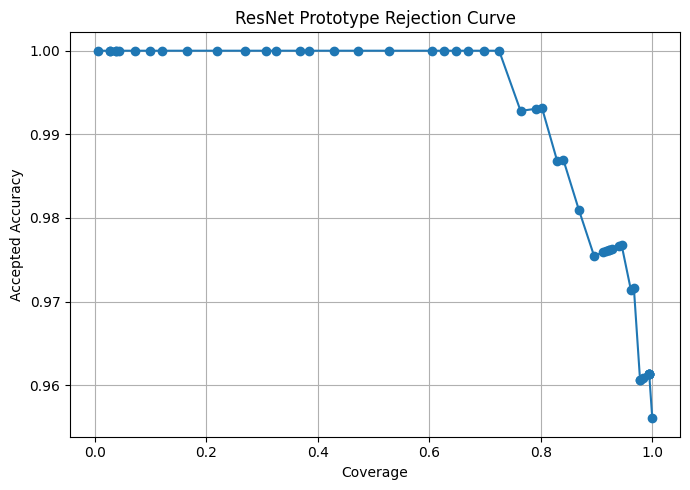

In [170]:
plt.figure(figsize=(7, 5))
plt.plot(reject_df["coverage"], reject_df["accepted_acc"], marker="o")
plt.xlabel("Coverage")
plt.ylabel("Accepted Accuracy")
plt.title("ResNet Prototype Rejection Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

In [171]:
soft_threshold = float(soft_row['threshold'])
accept_mask = val_scores_resnet.numpy() >= soft_threshold

accepted_true = y_val_resnet_np[accept_mask]
accepted_preds = val_preds_resnet.numpy()[accept_mask]

print("Threshold:", soft_threshold)
print("Coverage:", accept_mask.mean())
print("Accepted accuracy:", accuracy_score(accepted_true, accepted_preds))

Threshold: 0.7612318992614746
Coverage: 0.7252747252747253
Accepted accuracy: 1.0


### Add unknown dataset to find best threshold

In [172]:
UNKNOWN_DIR = DATA_ROOT / "unknown_val"
unknown_dataset = ImageFolder(
    root=UNKNOWN_DIR,
    transform=eval_tf
)

unknown_loader = DataLoader(
    unknown_dataset,
    batch_size=32,
    shuffle=False
)

print("Unknown samples:", len(unknown_dataset))

Unknown samples: 173


In [ ]:
Z_unknown, _ = extract_embeddings(
    resnet_feat_extractor,
    unknown_loader,
    DEVICE
)

print(Z_unknown.shape) # ([173, 512])

torch.Size([173, 512])


In [174]:
Z_unknown_l2 = l2_normalize_torch(Z_unknown)

In [175]:
unknown_scores = Z_unknown_l2 @ prototypes.T

unknown_max_scores, _ = unknown_scores.max(dim=1)

unknown_max_scores = unknown_max_scores.cpu().numpy()

In [180]:
unknown_reject_soft = (unknown_max_scores < soft_threshold).mean()

print("soft_threshold:", soft_threshold)
print("unknown rejection @ soft_threshold:", unknown_reject_soft)

soft_threshold: 0.7612318992614746
unknown rejection @ soft_threshold: 0.976878612716763


In [181]:
soft_row = reject_df.iloc[(reject_df["threshold"] - soft_threshold).abs().argsort()[:1]]

print("Soft threshold row:")
print(soft_row[["threshold", "coverage", "accepted_acc"]])

Soft threshold row:
    threshold  coverage  accepted_acc
25   0.761232  0.725275           1.0


In [190]:
# known validation scores from prototype similarity
val_sims_known = Z_resnet_val_l2 @ prototypes.T          # [N, C]
val_preds_known = torch.argmax(val_sims_known, dim=1)    # [N]
val_scores_known = val_sims_known.max(dim=1).values      # [N]

# convert to numpy and force 1D
y_val_known_np = np.asarray(y_val.numpy()).reshape(-1)
val_preds_known_np = np.asarray(val_preds_known.numpy()).reshape(-1)
val_scores_known_np = np.asarray(val_scores_known.numpy()).reshape(-1)

print("y_val_known_np shape:", y_val_known_np.shape)
print("val_preds_known_np shape:", val_preds_known_np.shape)
print("val_scores_known_np shape:", val_scores_known_np.shape)

y_val_known_np shape: (182,)
val_preds_known_np shape: (182,)
val_scores_known_np shape: (182,)


In [191]:
unknown_max_scores_np = np.asarray(unknown_max_scores).reshape(-1)
print("unknown_max_scores_np shape:", unknown_max_scores_np.shape)

unknown_max_scores_np shape: (173,)


In [192]:
candidate_thresholds = [0.70, 0.72, 0.74, 0.76]

rows = []
for t in candidate_thresholds:
    known_accept_mask = val_scores_known_np >= t
    known_coverage = known_accept_mask.mean()

    if known_accept_mask.sum() > 0:
        known_acc = accuracy_score(
            y_val_known_np[known_accept_mask],
            val_preds_known_np[known_accept_mask]
        )
    else:
        known_acc = np.nan

    unknown_reject = (unknown_max_scores_np < t).mean()

    rows.append({
        "threshold": t,
        "known_coverage": known_coverage,
        "accepted_known_acc": known_acc,
        "unknown_reject_rate": unknown_reject
    })

threshold_compare_df = pd.DataFrame(rows)
threshold_compare_df

,threshold,known_coverage,accepted_known_acc,unknown_reject_rate
0,0.70,0.928571,0.976331,0.878613
1,0.72,0.917582,0.976048,0.936416
2,0.74,0.829670,0.986755,0.965318
3,0.76,0.741758,1.000000,0.976879


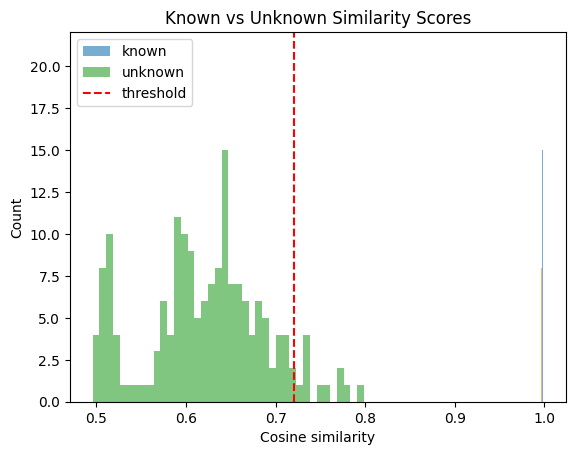

In [193]:
final_threshold = 0.72
plt.hist(val_scores.numpy(), bins=40, alpha=0.6, label="known")
plt.hist(unknown_max_scores, bins=40, alpha=0.6, label="unknown")

plt.axvline(final_threshold, color="red", linestyle="--", label="threshold")

plt.legend()
plt.title("Known vs Unknown Similarity Scores")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")

plt.show()

In [194]:
unknown_reject_rate = (unknown_max_scores < final_threshold).mean()

print("Unknown rejection rate:", unknown_reject_rate)

Unknown rejection rate: 0.9364161849710982


## Section 13 Test on sample and export model

In [195]:
# function for running a test image
from PIL import Image

def predict_single_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = resnet_feat_extractor(x)
        emb = outputs["emb"]
        emb = torch.flatten(emb, start_dim=1)

        emb_l2 = l2_normalize_torch(emb)

        prototypes_device = prototypes.to(DEVICE)
        sims = emb_l2 @ prototypes_device.T

        score, pred = sims.max(dim=1)

        score = score.item()
        pred = pred.item()

        if score >= final_threshold:
            label = CLASS_NAMES[pred]
        else:
            label = "REJECT"

    print("Prediction:", label)
    print("Confidence (cos similiarity):", score)

    return label, score

In [196]:
# test
print("leaf--reject")
predict_single_image("testing1.jpg") # leaf
print()
print("apple--reject")
predict_single_image("testing2.jpg") # apple
print()
print("corrosion")
predict_single_image("5011.jpg") # corrosion
print()
print("corrosion")
predict_single_image("testing3.jpg") # corrosion

leaf--reject
Prediction: REJECT
Confidence (cos similiarity): 0.6488191485404968

apple--reject
Prediction: NOCORROSION
Confidence (cos similiarity): 0.7541995048522949

corrosion
Prediction: REJECT
Confidence (cos similiarity): 0.6761451363563538

corrosion
Prediction: CORROSION
Confidence (cos similiarity): 0.8168373703956604


('CORROSION', 0.8168373703956604)

In [198]:
# start exporting the model bundle

bundle = {
    "model_state_dict": resnet_l4_model.state_dict(),
    "prototypes": prototypes.cpu(),
    "threshold": float(final_threshold),
    "class_names": CLASS_NAMES
}

torch.save(bundle, "resnet_prototype_bundle.pt")

print("Bundle saved")

Bundle saved
